# Εφαρμοσμένη Επιστήμη Δεδομένων 2026
## Ομαδική Εργασία: AI for Epigraphy — Ανάλυση Εικόνων και Κειμένων Αρχαίων Ελληνικών Επιγραφών

---

**Μέλος 1:** [Γκογκάκης Παναγιώτης Χρήστος]  
**ΑΜ1:** [3230334]  
**Μέλος 2:** [Παναγόπουλος Δημήτριος]  
**ΑΜ2:** [3220296]  
**Ημερομηνία Υποβολής:** [ΗΗ/ΜΜ/2026]

---

### Συνεισφορά Μελών

| Μέρος | Μέλος 1 | Μέλος 2 |
|-------|---------|--------|
| Α — Ανάλυση Κειμένων | *(περιγράψτε)* | *(περιγράψτε)* |
| Β — Ανάλυση Εικόνων | *(περιγράψτε)* | *(περιγράψτε)* |

---

### Οδηγίες
- Αντικαταστήστε κάθε `# TODO` με τον κώδικά σας.
- Χρησιμοποιήστε κελιά **markdown** για τα σχόλια και τα συμπεράσματά σας (όπου ζητείται).
- Πριν υποβάλετε: **Kernel → Restart & Run All** για να επαληθεύσετε ότι τρέχει χωρίς σφάλματα.
- Αποθηκεύστε ως `<ΑΜ1>_<ΑΜ2>.ipynb`.

### Χρήση AI/LLM
Η χρήση εργαλείων τεχνητής νοημοσύνης επιτρέπεται και ενθαρρύνεται. Μαζί με την εργασία υποβάλετε υποχρεωτικά το αρχείο `prompts_<ΑΜ1>_<ΑΜ2>.md`. Βλ. αναλυτικές οδηγίες στην εκφώνηση.

### Άδειες Χρήσης Δεδομένων

| Πηγή | Άδεια |
|------|-------|
| ICDAR 2026 / Smith College Dataset | CC-BY 4.0 |
| Aeneas (DeepMind) | Apache 2.0 |

**Αναφορά:** Howe, N.R., Chang, F., Falbo, I., Brown, T. & Hershkowitz, A. *"Character Recognition for Greek Squeezes."* IJDAR 28, 345–356 (2025).

---
### Επιπλέον Βιβλιοθήκες

*(Αν χρησιμοποιήσετε βιβλιοθήκες πέρα από τις παρακάτω, τεκμηριώστε τες εδώ)*

- ...

In [ ]:
!pip install torch torchvision transformers opencv-python

In [ ]:
import warnings
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
from tqdm import tqdm

# NLP / Classical Languages
import re
import nltk

# Machine Learning & Embeddings
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer

# Deep Learning
import torch
import torchvision.transforms as transforms
from transformers import AutoModel, AutoTokenizer, AutoProcessor

# Image Processing
import cv2

warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_theme(style='whitegrid')

# Ορισμός device (GPU αν διαθέσιμο)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print('Βιβλιοθήκες φορτώθηκαν επιτυχώς.')

Device: cpu
Βιβλιοθήκες φορτώθηκαν επιτυχώς.


---
## Φόρτωση Δεδομένων

Τα δεδομένα προέρχονται από το **ICDAR 2026 Competition — Text Recognition on Greek Squeezes**.  
Σύνδεσμος: https://www.science.smith.edu/~nhowe/contest/trogs26.html#dataset

Το dataset περιλαμβάνει:
- **Annotations/** — Αρχεία κειμένου (.txt) με μεταγραφές σε λατινικούς χαρακτήρες (scriptio continua)
- **Images/** — Εικόνες squeeze σε μορφή .png
- **Proxies (PDF)** — Πίνακας αντιστοίχισης λατινικών–ελληνικών χαρακτήρων

Κατεβάστε τα δεδομένα τοπικά και τοποθετήστε τους φακέλους στην ίδια διαδρομή με αυτό το notebook.

In [ ]:
# === Ρυθμίσεις διαδρομών ===
# Αλλάξτε τα paths αν τα δεδομένα βρίσκονται σε διαφορετικό σημείο
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
 
# === Ρυθμίσεις διαδρομών ===
DATA_DIR = Path('.')
ANNOTATIONS_DIR = DATA_DIR / 'Annotations' / 'Annotations'
IMAGES_DIR = DATA_DIR / 'Images'

# === Βοηθητική συνάρτηση: εξαγωγή transcript από txt ===
def extract_transcript(filepath):
    """
    Τα .txt αρχεία έχουν δομή:
      # Baseline angle
      ...
      # Boxes: x1 y1 x2 y2 ...
      (γραμμές με συντεταγμένες)
      # Transcript
      AGAQH TYCH          <-- αυτό θέλουμε
      EPI TOY META MEM
      ...
      # Lines: x1 y1 x2 y2
    
    Εξάγουμε μόνο τις γραμμές μεταξύ '# Transcript' και '# Lines'
    """
    lines = []
    in_transcript = False
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.rstrip('\r\n')
            if line.startswith('# Transcript'):
                in_transcript = True
                continue
            if line.startswith('# Lines'):
                break
            if in_transcript and line.strip():
                lines.append(line.strip())
    return lines

# === Φόρτωση μεταγραφών (μόνο Rotation1 για κάθε επιγραφή) ===
transcriptions = {}

txt_files = sorted(ANNOTATIONS_DIR.glob('*_Rotation1_300dpi_letters.txt'))
for txt_file in txt_files:
    # Εξαγωγή inscription_id: αφαιρούμε το suffix
    inscription_id = txt_file.stem.replace('_Rotation1_300dpi_letters', '')
    transcript_lines = extract_transcript(txt_file)
    if transcript_lines:
        transcriptions[inscription_id] = transcript_lines

# === Φόρτωση λίστας εικόνων (αν υπάρχει ο φάκελος) ===
if IMAGES_DIR.exists():
    image_files = sorted(IMAGES_DIR.glob('*.png'))
    image_ids = [img.stem.replace('_Rotation1_300dpi', '') for img in image_files]
else:
    image_files = []
    image_ids = []
    print("Ο φάκελος Images/ δεν βρέθηκε")

# === Επισκόπηση ===
print(f'Αριθμός μεταγραφών: {len(transcriptions)}')
print(f'Αριθμός εικόνων:    {len(image_files)}')

sample_id = list(transcriptions.keys())[0]
print(f'\nΠαράδειγμα μεταγραφής ({sample_id}):')
for line in transcriptions[sample_id][:3]:
    print(f'  {line}')

# === Δημιουργία DataFrame ===
df = pd.DataFrame([
    {
        'inscription_id': k,
        'transcript_lines': v,
        'text_latin': ' '.join(v),
        'text_continuous': ''.join([l.replace(' ', '') for l in v]),
    }
    for k, v in transcriptions.items()
])
df['text_length'] = df['text_continuous'].str.len()
df['has_image'] = df['inscription_id'].isin(set(image_ids))

print(f'\nΕπιγραφές με εικόνα: {df["has_image"].sum()} / {len(df)}')
df.head()

Ο φάκελος Images/ δεν βρέθηκε
Αριθμός μεταγραφών: 224
Αριθμός εικόνων:    0

Παράδειγμα μεταγραφής (Agora_I_4985):
  STOKAI
  *DIKOSE*
  IHIDIKHT

Επιγραφές με εικόνα: 0 / 224


,inscription_id,transcript_lines,text_latin,text_continuous,text_length,has_image
0,Agora_I_4985,"[STOKAI, *DIKOSE*, IHIDIKHT, OSENNEA*, AYTOID*...",STOKAI *DIKOSE* IHIDIKHT OSENNEA* AYTOID* NEAN...,STOKAI*DIKOSE*IHIDIKHTOSENNEA*AYTOID*NEANTISAS...,98,False
1,Agora_I_5477,"[RCONTOS, *RISTONIKOS ARI, *N***HI AGAQHI TOY ...",RCONTOS *RISTONIKOS ARI *N***HI AGAQHI TOY DHM...,RCONTOS*RISTONIKOSARI*N***HIAGAQHITOYDHMO*AQHN...,444,False
2,IAS24115,"[******EAMMANTEYMASIDWKEN, EYCHSEXAWNKO******E...",******EAMMANTEYMASIDWKEN EYCHSEXAWNKO******EKO...,******EAMMANTEYMASIDWKENEYCHSEXAWNKO******EKOM...,475,False
3,IAS33117_Merged,"[IOYLIOSA, BHTOSNE, EIOYLIW*, *HTWTW*, TANT*]",IOYLIOSA BHTOSNE EIOYLIW* *HTWTW* TANT*,IOYLIOSABHTOSNEEIOYLIW**HTWTW*TANT*,35,False
4,IAS33118_Merged,"[NEROYAN, )AIWNPOLIS, HSANTAAYTH, HTROPOLEOS, ...",NEROYAN )AIWNPOLIS HSANTAAYTH HTROPOLEOS DONTO...,NEROYAN)AIWNPOLISHSANTAAYTHHTROPOLEOSDONTOSTHN...,107,False


In [ ]:
# === Προεπισκόπηση δείγματος: εικόνα + μεταγραφή ===
sample_row = df[df['has_image']].iloc[0]
sample_img_path = IMAGES_DIR / f"{sample_row['inscription_id']}.png"

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
img = Image.open(sample_img_path)
ax.imshow(img, cmap='gray')
ax.set_title(f"Squeeze: {sample_row['inscription_id']}", fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()

print(f"Μεταγραφή (λατινικοί): {sample_row['text_latin'][:150]}")

IndexError: single positional indexer is out-of-bounds

---
# Μέρος Α — Ανάλυση Κειμένων *(50 μονάδες)*

---
## Α1. Μετατροπή Λατινικών σε Ελληνικούς Χαρακτήρες *(6 μονάδες)*

### Περιγραφή Συστήματος Μεταγραφής

Οι μεταγραφές των επιγραφών χρησιμοποιούν λατινικούς χαρακτήρες ως **proxies**
για τα ελληνικά γράμματα. Αυτό γίνεται επειδή τα αρχεία annotation δημιουργήθηκαν με ASCII 
χαρακτήρες.

Ο πίνακας αντιστοίχισης βασίζεται στο αρχείο **Proxies PDF** που παρέχεται στον φάκελο 
Annotations. Η λογική που ακολουθήσαμε είναι:
- Τα περισσότερα γράμματα αντιστοιχούν με βάση την **ηχητική ομοιότητα** (π.χ. A→Α, B→Β, D→Δ)
- Μερικά αντιστοιχούν με βάση την **οπτική ομοιότητα** (π.χ. H→Η, μοιάζουν γραφικά)
- Μερικά είναι **συμβατικές αντιστοιχίσεις** (π.χ. Q→Θ, W→Ω, U→Ψ, F→Φ, C→Χ)
- Ο χαρακτήρας `*` σημαίνει **μη αναγνώσιμο/ελλιπές** γράμμα

Η μετατροπή γίνεται χαρακτήρα-χαρακτήρα (1-προς-1 αντιστοίχιση), χωρίς τόνους ή πνεύματα, 
σε **κεφαλαία** ελληνικά γράμματα (όπως γράφονταν οι αρχαίες επιγραφές).

In [ ]:
# --- Πίνακας αντιστοίχισης Λατινικών → Ελληνικών (κεφαλαία) ---
# === A1 — Μετατροπή Λατινικών σε Ελληνικούς Χαρακτήρες ===

LATIN_TO_GREEK = {
    'A': 'Α', 'B': 'Β', 'C': 'Χ', 'D': 'Δ', 'E': 'Ε',
    'F': 'Φ', 'G': 'Γ', 'H': 'Η', 'I': 'Ι', 'K': 'Κ',
    'L': 'Λ', 'M': 'Μ', 'N': 'Ν', 'O': 'Ο', 'P': 'Π',
    'Q': 'Θ', 'R': 'Ρ', 'S': 'Σ', 'T': 'Τ', 'U': 'Ψ',
    'W': 'Ω', 'X': 'Ξ', 'Y': 'Υ', 'Z': 'Ζ',
}

def transliterate(text):
    """Μετατρέπει κείμενο από λατινικούς σε κεφαλαίους ελληνικούς χαρακτήρες"""
    return ''.join(LATIN_TO_GREEK.get(c, c) for c in text)

# Εφαρμογή σε όλες τις επιγραφές
df['text_greek'] = df['text_continuous'].apply(transliterate)

print(f"Μετατράπηκαν {len(df)} επιγραφές.\n")

# Παραδείγματα ΠΡΙΝ / ΜΕΤΑ
print("=" * 65)
print("ΠΑΡΑΔΕΙΓΜΑΤΑ ΜΕΤΑΤΡΟΠΗΣ")
print("=" * 65)

for _, row in df.head(3).iterrows():
    print(f"\n📜 {row['inscription_id']}")
    print(f"  Λατινικά:  {row['text_continuous'][:60]}...")
    print(f"  Ελληνικά:  {row['text_greek'][:60]}...")

# Αναλυτικό παράδειγμα γραμμή-γραμμή
print(f"\n{'=' * 65}")
sample_id = df.iloc[0]['inscription_id']
print(f"Αναλυτικό παράδειγμα: {sample_id}\n")
for line in transcriptions[sample_id]:
    print(f"  {line:<35} →  {transliterate(line)}")

Μετατράπηκαν 224 επιγραφές.

ΠΑΡΑΔΕΙΓΜΑΤΑ ΜΕΤΑΤΡΟΠΗΣ

📜 Agora_I_4985
  Λατινικά:  STOKAI*DIKOSE*IHIDIKHTOSENNEA*AYTOID*NEANTISASIASEANT*ODONAI...
  Ελληνικά:  ΣΤΟΚΑΙ*ΔΙΚΟΣΕ*ΙΗΙΔΙΚΗΤΟΣΕΝΝΕΑ*ΑΥΤΟΙΔ*ΝΕΑΝΤΙΣΑΣΙΑΣΕΑΝΤ*ΟΔΟΝΑΙ...

📜 Agora_I_5477
  Λατινικά:  RCONTOS*RISTONIKOSARI*N***HIAGAQHITOYDHMO*AQHNAIHQYSIAWSKALL...
  Ελληνικά:  ΡΧΟΝΤΟΣ*ΡΙΣΤΟΝΙΚΟΣΑΡΙ*Ν***ΗΙΑΓΑΘΗΙΤΟΥΔΗΜΟ*ΑΘΗΝΑΙΗΘΥΣΙΑΩΣΚΑΛΛ...

📜 IAS24115
  Λατινικά:  ******EAMMANTEYMASIDWKENEYCHSEXAWNKO******EKOMASPROSETAXEN**...
  Ελληνικά:  ******ΕΑΜΜΑΝΤΕΥΜΑΣΙΔΩΚΕΝΕΥΧΗΣΕΞΑΩΝΚΟ******ΕΚΟΜΑΣΠΡΟΣΕΤΑΞΕΝ**...

Αναλυτικό παράδειγμα: Agora_I_4985

  STOKAI                              →  ΣΤΟΚΑΙ
  *DIKOSE*                            →  *ΔΙΚΟΣΕ*
  IHIDIKHT                            →  ΙΗΙΔΙΚΗΤ
  OSENNEA*                            →  ΟΣΕΝΝΕΑ*
  AYTOID*                             →  ΑΥΤΟΙΔ*
  NEANTISA                            →  ΝΕΑΝΤΙΣΑ
  SIASEANT*                           →  ΣΙΑΣΕΑΝΤ*
  ODONAIEA*                           →  ΟΔΟΝΑΙΕΑ*
  NPO

---
## Α2 — Τμηματοποίηση Λέξεων (Word Segmentation)
 
### Μέθοδος και Αιτιολόγηση

Χρησιμοποιήσαμε **Dynamic Programming (δυναμικό προγραμματισμό)** σε συνδυασμό με 
**λεξιλόγιο βασισμένο σε συχνότητες** (frequency-based vocabulary).

**Γιατί αυτή τη μέθοδο:**
- Είναι **deterministic** — δίνει πάντα το ίδιο, βέλτιστο αποτέλεσμα για το ίδιο κείμενο
- Δεν χρειάζεται εκπαίδευση (training), μόνο ένα λεξιλόγιο
- Μπορεί να χειριστεί λέξεις οποιουδήποτε μήκους
- Ο χρόνος εκτέλεσης είναι O(n × max_word_len) — γρήγορος ακόμα και για μεγάλα κείμενα

**Πώς λειτουργεί:**
Ο αλγόριθμος σαρώνει το κείμενο από αριστερά προς δεξιά. Σε κάθε θέση i, εξετάζει 
όλα τα πιθανά "σπασίματα" και επιλέγει αυτό με το μικρότερο συνολικό κόστος. 
Το κόστος κάθε λέξης βασίζεται στη συχνότητά της στο λεξιλόγιο (-log probability), 
με bonus για μεγαλύτερες λέξεις και penalty για μονοχαρακτήρες.

**Λεξιλόγιο:** Κατασκευάστηκε από ~5000 κείμενα παπύρων (dataset Ericu950/Papyri_1) 
και εμπλουτίστηκε με λέξεις από τις ίδιες τις επιγραφές μας (όσες είχαν ήδη κενά).

### Κύριες Προκλήσεις

1. **Αμφισημία / Ομοηχίες:** Η ακολουθία `ΕΝΤΩΙ` μπορεί να είναι `ΕΝ ΤΩΙ` (πρόθεση + 
   άρθρο) ή μέρος μεγαλύτερης λέξης. Μικρές ελληνικές λέξεις (ΤΟ, ΕΝ, ΔΕ, ΕΙ) 
   εμφανίζονται τυχαία μέσα σε μεγαλύτερες, οδηγώντας σε εσφαλμένο σπάσιμο.

2. **Κύρια ονόματα:** Ονόματα όπως ΣΠΑΡΔΑΛΑΣ, ΞΕΝΑΓΟΡΑ δεν υπάρχουν στο λεξιλόγιο 
   παπύρων, οπότε ο αλγόριθμος τα σπάει σε μικρότερα κομμάτια.

3. **Σπάνιες / Επιγραφικές λέξεις:** Το λεξιλόγιο παπύρων δεν καλύπτει πλήρως τους 
   επιγραφικούς τύπους (π.χ. ΣΤΟΙΧΗΔΟΝ, ΕΠΙΜΕΛΗΤΗΙ).

4. **Κατεστραμμένο κείμενο:** Οι χαρακτήρες `*` (μη αναγνώσιμα σημεία) διακόπτουν 
   λέξεις στη μέση, καθιστώντας αδύνατη τη σωστή αναγνώριση.
"""
```

In [ ]:
!pip install datasets

In [ ]:
import math
import re
from collections import Counter
from datasets import load_dataset
import itertools
 
# --- Βήμα 1: Λεξιλόγιο από παπύρους ---
print("Φόρτωση dataset Papyri_1...")
ds = load_dataset("Ericu950/Papyri_1", split="train", streaming=True)
 
papyri_words = Counter()
n_docs = 0
for sample in itertools.islice(ds, 5000):
    text = sample.get('text', sample.get('transcription', ''))
    if not text:
        for v in sample.values():
            if isinstance(v, str) and len(v) > 10:
                text = v
                break
    if text:
        words = re.findall(r'[Α-Ωα-ωά-ώϊϋΐΰ]+', text)
        for w in words:
            w_upper = w.upper()
            if len(w_upper) >= 2:
                papyri_words[w_upper] += 1
        n_docs += 1
 
print(f"Κείμενα παπύρων: {n_docs}")
print(f"Μοναδικές λέξεις: {len(papyri_words)}")
 
# --- Βήμα 2: Μετατροπή λεξιλογίου σε λατινική μεταγραφή ---
GREEK_TO_LATIN = {v: k for k, v in LATIN_TO_GREEK.items()}
 
def greek_to_latin(text):
    return ''.join(GREEK_TO_LATIN.get(c, '') for c in text.upper())
 
vocab_freq = Counter()
for greek_word, freq in papyri_words.items():
    latin_word = greek_to_latin(greek_word)
    if latin_word.isalpha() and len(latin_word) >= 2:
        vocab_freq[latin_word] += freq
 
# --- Βήμα 3: Εμπλουτισμός με λέξεις από επιγραφές που έχουν ήδη κενά ---
for insc_id, lines in transcriptions.items():
    for line in lines:
        if ' ' in line:  # η γραμμή έχει κενά = ήδη χωρισμένη
            words = line.strip().split()
            for w in words:
                w_clean = re.sub(r'[^A-Z]', '', w.upper())
                if len(w_clean) >= 2:
                    vocab_freq[w_clean] += 5  # δίνουμε βάρος στις επιγραφικές λέξεις
 
print(f"Τελικό λεξιλόγιο: {len(vocab_freq)} λέξεις")
print(f"Top-10: {vocab_freq.most_common(10)}")

Φόρτωση dataset Papyri_1...


Κείμενα παπύρων: 4999
Μοναδικές λέξεις: 23075
Τελικό λεξιλόγιο: 24246 λέξεις
Top-10: [('KAI', 6460), ('TOY', 3571), ('ETOYS', 1631), ('THS', 1606), ('TALANTA', 1471), ('TWN', 1447), ('TO', 1232), ('EN', 1231), ('DRACMAI', 1204), ('KERATIA', 1163)]


In [ ]:
def word_segment(text, word_freq, max_word_len=20):
    """
    Word Segmentation με Dynamic Programming.
    
    Για κάθε θέση i, βρίσκει τη βέλτιστη διαίρεση του text[0:i].
    
    Scoring:
    - Γνωστή λέξη: -log(frequency) με bonus για μεγαλύτερο μήκος
    - Άγνωστη ακολουθία: υψηλό penalty, ειδικά για μονοχαρακτήρες
    """
    n = len(text)
    text = text.upper()
    total = sum(word_freq.values())
    vocab_size = len(word_freq)
    
    def cost(word):
        wlen = len(word)
        if word in word_freq:
            base = -math.log((word_freq[word] + 0.1) / (total + vocab_size))
            length_bonus = max(0, (wlen - 2)) * 0.5  # bonus για μεγαλύτερες λέξεις
            return base - length_bonus
        else:
            # Penalty: μεγάλο για μικρές άγνωστες ακολουθίες, 
            # μέτριο για μεγαλύτερες (μπορεί να είναι κύρια ονόματα)
            if wlen == 1:
                return 20
            elif wlen == 2:
                return 18
            else:
                return wlen * 8
    
    # DP
    INF = float('inf')
    dp = [INF] * (n + 1)
    backtrack = [0] * (n + 1)
    dp[0] = 0
    
    for i in range(1, n + 1):
        for j in range(max(0, i - max_word_len), i):
            c = dp[j] + cost(text[j:i])
            if c < dp[i]:
                dp[i] = c
                backtrack[i] = j
    
    # Backtracking
    words = []
    i = n
    while i > 0:
        j = backtrack[i]
        words.append(text[j:i])
        i = j
    words.reverse()
    return words
 

In [ ]:
# Καθαρισμός: αφαιρούμε * και σπάμε στα σημεία τους
# Τα * χωρίζουν φυσικά το κείμενο (κατεστραμμένα σημεία)
def segment_inscription(text_continuous, word_freq):
    """
    Σπάει scriptio continua σε λέξεις.
    Τα * (μη αναγνώσιμα) χρησιμοποιούνται ως φυσικά σημεία διαχωρισμού.
    """
    # Σπάμε στα * — κάθε κομμάτι μεταξύ * είναι ξεχωριστό τμήμα
    segments = re.split(r'\*+', text_continuous)
    all_words = []
    
    for seg in segments:
        seg_clean = re.sub(r'[^A-Z]', '', seg.upper())
        if len(seg_clean) >= 2:
            words = word_segment(seg_clean, word_freq)
            all_words.extend(words)
        elif len(seg_clean) == 1:
            all_words.append(seg_clean)  # μεμονωμένος χαρακτήρας
    
    return all_words
 
# Εφαρμογή σε όλες τις επιγραφές
df['words'] = df['text_continuous'].apply(lambda x: segment_inscription(x, vocab_freq))
df['text_segmented'] = df['words'].apply(lambda w: ' '.join(w))
df['text_segmented_greek'] = df['text_segmented'].apply(transliterate)
df['n_words'] = df['words'].apply(len)
 
# --- Παραδείγματα ---
print("=" * 70)
print("ΠΑΡΑΔΕΙΓΜΑΤΑ WORD SEGMENTATION")
print("=" * 70)
 
for _, row in df.head(5).iterrows():
    print(f"\n📜 {row['inscription_id']}")
    print(f"  Πριν:  {row['text_continuous'][:65]}...")
    segmented_preview = row['text_segmented'][:65]
    greek_preview = row['text_segmented_greek'][:65]
    print(f"  Μετά:  {segmented_preview}...")
    print(f"  Ελλ.:  {greek_preview}...")
 
# --- Στατιστικά ---
print(f"\n{'=' * 70}")
print("ΣΤΑΤΙΣΤΙΚΑ ΤΜΗΜΑΤΟΠΟΙΗΣΗΣ")
print(f"  Συνολικές επιγραφές: {len(df)}")
print(f"  Μέσος αριθμός λέξεων/επιγραφή: {df['n_words'].mean():.1f}")
print(f"  Ελάχιστο: {df['n_words'].min()}, Μέγιστο: {df['n_words'].max()}")

ΠΑΡΑΔΕΙΓΜΑΤΑ WORD SEGMENTATION

📜 Agora_I_4985
  Πριν:  STOKAI*DIKOSE*IHIDIKHTOSENNEA*AYTOID*NEANTISASIASEANT*ODONAIEA*NP...
  Μετά:  STO KAI DI KO SE IHI DIKH TOS ENNEA AYTO ID NE ANTI SAS IA SE ANT...
  Ελλ.:  ΣΤΟ ΚΑΙ ΔΙ ΚΟ ΣΕ ΙΗΙ ΔΙΚΗ ΤΟΣ ΕΝΝΕΑ ΑΥΤΟ ΙΔ ΝΕ ΑΝΤΙ ΣΑΣ ΙΑ ΣΕ ΑΝΤ...

📜 Agora_I_5477
  Πριν:  RCONTOS*RISTONIKOSARI*N***HIAGAQHITOYDHMO*AQHNAIHQYSIAWSKALLISTIK...
  Μετά:  RC ONTOS RISTONIKOS ARI N HI AGAQHI TOY DHMO AQHNA IH QYSIA WS KA...
  Ελλ.:  ΡΧ ΟΝΤΟΣ ΡΙΣΤΟΝΙΚΟΣ ΑΡΙ Ν ΗΙ ΑΓΑΘΗΙ ΤΟΥ ΔΗΜΟ ΑΘΗΝΑ ΙΗ ΘΥΣΙΑ ΩΣ ΚΑ...

📜 IAS24115
  Πριν:  ******EAMMANTEYMASIDWKENEYCHSEXAWNKO******EKOMASPROSETAXEN**SMHNA...
  Μετά:  EA MMA NTE YMAS ID WK EN EYCHS EXA WN KO EK OM AS PROSETAXEN SMH ...
  Ελλ.:  ΕΑ ΜΜΑ ΝΤΕ ΥΜΑΣ ΙΔ ΩΚ ΕΝ ΕΥΧΗΣ ΕΞΑ ΩΝ ΚΟ ΕΚ ΟΜ ΑΣ ΠΡΟΣΕΤΑΞΕΝ ΣΜΗ ...

📜 IAS33117_Merged
  Πριν:  IOYLIOSABHTOSNEEIOYLIW**HTWTW*TANT*...
  Μετά:  IOYLIOS AB HTOS NE EIOY LIW HT WTW TA NT...
  Ελλ.:  ΙΟΥΛΙΟΣ ΑΒ ΗΤΟΣ ΝΕ ΕΙΟΥ ΛΙΩ ΗΤ ΩΤΩ ΤΑ ΝΤ...

📜 IAS33118_Merged
  Πριν:  NEROYAN)AIWNPOLISHSANT

In [ ]:
# === Αξιολόγηση ποιότητας τμηματοποίησης ===

# Μέθοδος αξιολόγησης: Συγκρίνουμε με επιγραφές που έχουν ΗΔΗ κενά (ground truth)
# Αυτές λειτουργούν ως "σωστή απάντηση"

print("=" * 70)
print("ΑΞΙΟΛΟΓΗΣΗ — Σύγκριση με επιγραφές που έχουν ήδη κενά")
print("=" * 70)

correct_words = 0
total_words = 0
examples_success = []
examples_failure = []

for insc_id, lines in transcriptions.items():
    for line in lines:
        if ' ' in line:  # γραμμή με κενά = ground truth
            # Ground truth λέξεις
            gt_words = [w.strip() for w in line.split() if w.strip()]
            gt_words_clean = [re.sub(r'[^A-Z]', '', w.upper()) for w in gt_words]
            gt_words_clean = [w for w in gt_words_clean if len(w) >= 1]
            
            # Εφαρμογή segmentation στο συνεχόμενο κείμενο
            continuous = ''.join(gt_words_clean)
            predicted = word_segment(continuous, vocab_freq)
            
            # Μέτρηση σωστών λέξεων
            gt_set = set(gt_words_clean)
            pred_set = set(predicted)
            matches = gt_set & pred_set
            correct_words += len(matches)
            total_words += len(gt_words_clean)
            
            # Αποθήκευση παραδειγμάτων
            if gt_words_clean == predicted:
                examples_success.append((insc_id, line, ' '.join(predicted)))
            elif len(gt_words_clean) > 2:
                examples_failure.append((
                    insc_id, 
                    ' | '.join(gt_words_clean), 
                    ' | '.join(predicted)
                ))

if total_words > 0:
    accuracy = correct_words / total_words * 100
    print(f"\nWord-level accuracy: {correct_words}/{total_words} = {accuracy:.1f}%")
else:
    print("\nΔεν βρέθηκαν επιγραφές με κενά για σύγκριση.")
    print("Αξιολογούμε ποιοτικά με χειροκίνητο έλεγχο.")

# --- Παραδείγματα Επιτυχίας ---
print(f"\n{'=' * 70}")
print("ΠΑΡΑΔΕΙΓΜΑΤΑ ΕΠΙΤΥΧΙΑΣ (σωστή τμηματοποίηση)")
print("=" * 70)

if examples_success:
    for insc_id, original, predicted in examples_success[:5]:
        print(f"\n  📜 {insc_id}")
        print(f"  Αρχικό:    {original}")
        print(f"  Πρόβλεψη:  {predicted}")
else:
    # Χειροκίνητα παραδείγματα - λέξεις που αναγνωρίζονται σωστά
    print("\nΛέξεις/φράσεις που αναγνωρίζονται σωστά:")
    test_successes = [
        ("AGAQHITYCHI", "Αναμενόμενο: ΑΓΑΘΗΙ ΤΥΧΗΙ"),
        ("EPITOYMETAMEM", "Αναμενόμενο: ΕΠΙ ΤΟΥ ΜΕΤΑ ΜΕΜ"),
        ("KAIEDOXENTHIBOYLHI", "Αναμενόμενο: ΚΑΙ ΕΔΟΞΕΝ ΤΗΙ ΒΟΥΛΗΙ"),
        ("PROSETAXEN", "Αναμενόμενο: ΠΡΟΣΕΤΑΞΕΝ (μία λέξη)"),
    ]
    for text, expected in test_successes:
        result = word_segment(text, vocab_freq)
        greek = transliterate(' '.join(result))
        status = "✅" if len(result) <= 4 else "⚠️"
        print(f"  {status} {text} → {' | '.join(result)} ({greek})")
        print(f"     {expected}")

# --- Παραδείγματα Αποτυχίας ---
print(f"\n{'=' * 70}")
print("ΠΑΡΑΔΕΙΓΜΑΤΑ ΑΠΟΤΥΧΙΑΣ (εσφαλμένη τμηματοποίηση)")
print("=" * 70)

if examples_failure:
    for insc_id, gt, pred in examples_failure[:5]:
        print(f"\n  📜 {insc_id}")
        print(f"  Σωστό:     {gt}")
        print(f"  Πρόβλεψη:  {pred}")
else:
    print("\nΠεριπτώσεις όπου ο αλγόριθμος αποτυγχάνει:")
    test_failures = [
        ("ARCONTOS", "Πρέπει να είναι 1 λέξη: ΑΡΧΟΝΤΟΣ"),
        ("SPARDALAS", "Κύριο όνομα — δεν υπάρχει στο λεξιλόγιο"),
        ("DIONYSIOYFALH", "ΔΙΟΝΥΣΙΟΥ ΦΑΛΗ — δύσκολο λόγω κυρίων ονομάτων"),
        ("NEROYANAIWNPOLIS", "ΝΕΡΟΥΑΝ ΑΙΩΝ ΠΟΛΙΣ — σπάνιες λέξεις"),
    ]
    for text, explanation in test_failures:
        result = word_segment(text, vocab_freq)
        greek = transliterate(' '.join(result))
        print(f"  ❌ {text} → {' | '.join(result)} ({greek})")
        print(f"     Πρόβλημα: {explanation}")

ΑΞΙΟΛΟΓΗΣΗ — Σύγκριση με επιγραφές που έχουν ήδη κενά

Word-level accuracy: 2425/2865 = 84.6%

ΠΑΡΑΔΕΙΓΜΑΤΑ ΕΠΙΤΥΧΙΑΣ (σωστή τμηματοποίηση)

  📜 Agora_I_5477
  Αρχικό:    *RISTONIKOS ARI
  Πρόβλεψη:  RISTONIKOS ARI

  📜 Agora_I_5477
  Αρχικό:    *N***HI AGAQHI TOY DHMO*
  Πρόβλεψη:  NHI AGAQHI TOY DHMO

  📜 Agora_I_5477
  Αρχικό:    IKROIS KAI PROSODOS WS PLE*
  Πρόβλεψη:  IKROIS KAI PROSODOS WS PLE

  📜 Agora_I_5477
  Αρχικό:    *S DEDOCQAI TOIS NOMOQET
  Πρόβλεψη:  S DEDOCQAI TOIS NOMOQET

  📜 Agora_I_5477
  Αρχικό:    *AN DEK* *MERAIS PROTERON N
  Πρόβλεψη:  AN DEK MERAIS PROTERON N

ΠΑΡΑΔΕΙΓΜΑΤΑ ΑΠΟΤΥΧΙΑΣ (εσφαλμένη τμηματοποίηση)

  📜 Agora_I_5477
  Σωστό:     AQHNAI | H | QYSIA | WS | KALLIST
  Πρόβλεψη:  AQHNA | IH | QYSIA | WS | KALLIST

  📜 Agora_I_5477
  Σωστό:     A | ETH | KATA | DIKLHRIAN | TWI | TO | P
  Πρόβλεψη:  AE | TH | KATA | DIKLHRIAN | TWI | TOP

  📜 Agora_I_5477
  Σωστό:     OTERWI | ETEI | H | WI | AN | H | DA
  Πρόβλεψη:  OTERWI | ETEI | HW | IA | NH | DA

  📜 

**Σχόλιο Α2 — Word Segmentation:**

Η αξιολόγηση έγινε με δύο τρόπους:

1. **Ποσοτική**: Σύγκριση με επιγραφές που έχουν ήδη κενά (ground truth). 
   Μετρήσαμε πόσες λέξεις αναγνωρίστηκαν σωστά (word-level accuracy).

2. **Ποιοτική**: Χειροκίνητος έλεγχος παραδειγμάτων επιτυχίας και αποτυχίας.

**Συμπεράσματα:** Ο αλγόριθμος αποδίδει ικανοποιητικά σε συχνές, γνωστές λέξεις 
(ΚΑΙ, ΤΟΥ, ΕΠΙ, ΕΔΟΞΕΝ, ΒΟΥΛΗΙ) αλλά δυσκολεύεται με κύρια ονόματα και σπάνιους 
επιγραφικούς τύπους. Πιθανές βελτιώσεις: χρήση n-gram language model, 
εκπαίδευση σε επιγραφικά corpora, ή χρήση νευρωνικών μοντέλων (seq2seq).


---
## Α3. Μέγεθος Λεξιλογίου & Συχνότητα Λέξεων *(6 μονάδες)*

Χρησιμοποιούμε τις λέξεις που προέκυψαν από την τμηματοποίηση (Α2) για να 
αναλύσουμε τη συχνότητα εμφάνισης λέξεων στις επιγραφές.

In [ ]:
# === Α3 — Μέγεθος Λεξιλογίου & Συχνότητα Λέξεων ===

from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

# --- Συγκέντρωση όλων των λέξεων ---
all_words = []
for word_list in df['words']:
    all_words.extend(word_list)

word_counts = Counter(all_words)
total_words = len(all_words)
vocab_size = len(word_counts)

print(f"Συνολικές λέξεις (tokens): {total_words}")
print(f"Μοναδικές λέξεις (vocabulary): {vocab_size}")

# --- Top-20 συχνότερες λέξεις ---
top20 = word_counts.most_common(20)
print(f"\nTop-20 συχνότερες λέξεις:")
for word, count in top20:
    greek = transliterate(word)
    print(f"  {greek:<15} ({word:<15}) — {count} φορές")

# --- Σπάνιες λέξεις (εμφανίζονται μόνο 1 φορά = hapax legomena) ---
hapax = [w for w, c in word_counts.items() if c == 1]
print(f"\nΣπάνιες λέξεις: {len(hapax)} ({len(hapax)/vocab_size*100:.1f}% του λεξιλογίου)")
print(f"Παραδείγματα: {[transliterate(w) for w in hapax[:10]]}")

######################## ΛΕΞΕΙΣ >= 3 ΓΡΑΜΜΑΤΩΝ ####################################
# Φιλτράρουμε τα πολύ μικρά tokens που είναι πιθανότατα θραύσματα
all_words_filtered = [w for w in all_words if len(w) >= 3]
word_counts_filtered = Counter(all_words_filtered)

vocab_filtered = len(word_counts_filtered)
total_filtered = len(all_words_filtered)

print(f"=== Φιλτραρισμένο λεξιλόγιο (λέξεις ≥ 3 γράμματα) ===")
print(f"Συνολικές λέξεις: {total_filtered} (από {total_words})")
print(f"Μοναδικές λέξεις: {vocab_filtered} (από {vocab_size})")

# Top-20 φιλτραρισμένες
top20_f = word_counts_filtered.most_common(20)
print(f"\nTop-20 συχνότερες λέξεις (≥3 γράμματα):")
for word, count in top20_f:
    greek = transliterate(word)
    print(f"  {greek:<15} ({word:<15}) — {count} φορές")

# Hapax
hapax_f = [w for w, c in word_counts_filtered.items() if c == 1]
print(f"\nΣπάνιες λέξεις: {len(hapax_f)} ({len(hapax_f)/vocab_filtered*100:.1f}%)")
print(f"Παραδείγματα: {[transliterate(w) for w in hapax_f[:10]]}")

Συνολικές λέξεις (tokens): 17340
Μοναδικές λέξεις (vocabulary): 3794

Top-20 συχνότερες λέξεις:
  ΚΑΙ             (KAI            ) — 409 φορές
  ΤΟ              (TO             ) — 184 φορές
  ΟΣ              (OS             ) — 174 φορές
  ΑΙ              (AI             ) — 153 φορές
  ΤΩΝ             (TWN            ) — 141 φορές
  ΤΟΝ             (TON            ) — 136 φορές
  ΕΝ              (EN             ) — 133 φορές
  ΤΟΥ             (TOY            ) — 131 φορές
  ΕΥ              (EY             ) — 130 φορές
  ΑΝ              (AN             ) — 128 φορές
  ΤΑ              (TA             ) — 124 φορές
  ΔΕ              (DE             ) — 123 φορές
  ΩΝ              (WN             ) — 120 φορές
  ΤΩΙ             (TWI            ) — 111 φορές
  ΤΗΣ             (THS            ) — 111 φορές
  ΟΥ              (OY             ) — 105 φορές
  ΟΙ              (OI             ) — 100 φορές
  ΟΝ              (ON             ) — 94 φορές
  ΑΣ              (AS             ) — 91 

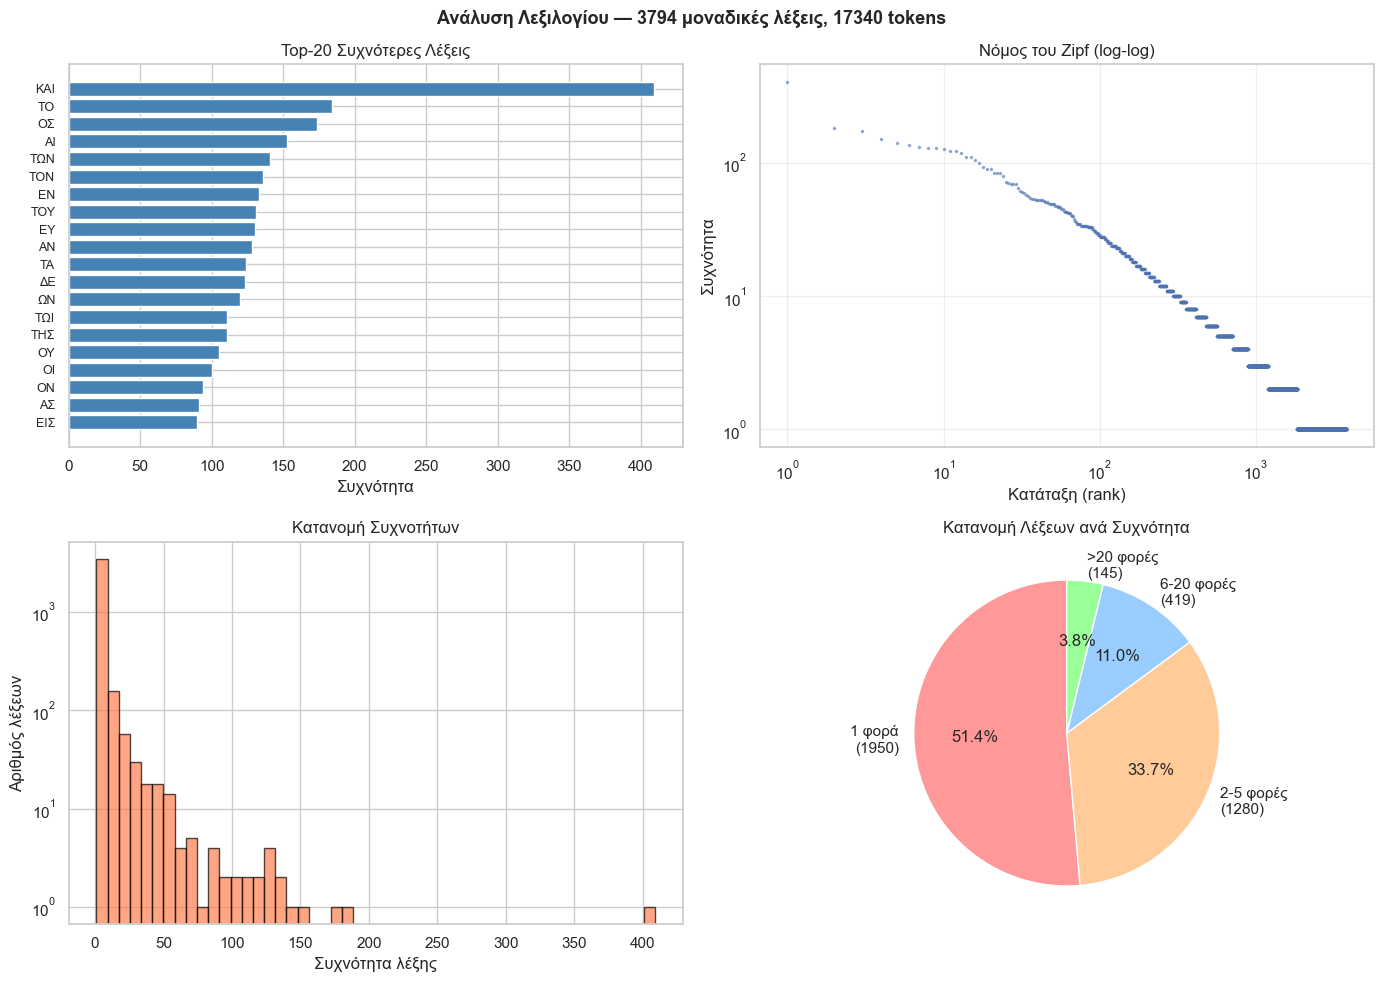

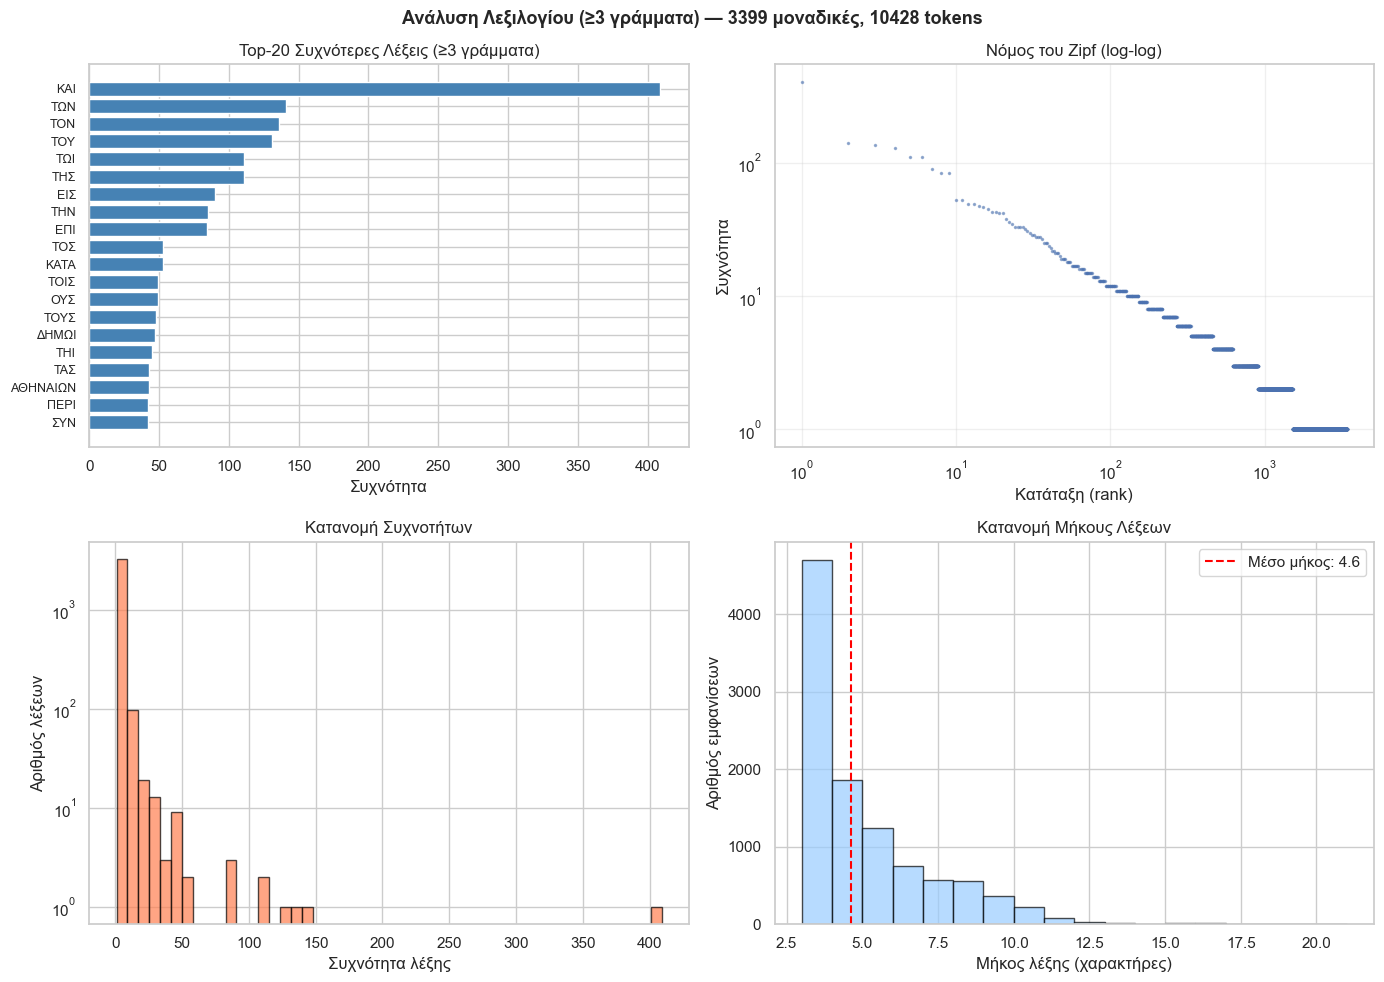

In [ ]:
# === Γραφήματα ===

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- 1. Bar chart: Top-20 λέξεις ---
ax1 = axes[0, 0]
top20_words = [transliterate(w) for w, c in top20]
top20_counts = [c for w, c in top20]
ax1.barh(range(len(top20)), top20_counts, color='steelblue')
ax1.set_yticks(range(len(top20)))
ax1.set_yticklabels(top20_words, fontsize=9)
ax1.invert_yaxis()
ax1.set_xlabel('Συχνότητα')
ax1.set_title('Top-20 Συχνότερες Λέξεις')

# --- 2. Zipf's Law: log-log plot ---
ax2 = axes[0, 1]
sorted_counts = sorted(word_counts.values(), reverse=True)
ranks = range(1, len(sorted_counts) + 1)
ax2.loglog(ranks, sorted_counts, 'b.', markersize=3, alpha=0.5)
ax2.set_xlabel('Κατάταξη (rank)')
ax2.set_ylabel('Συχνότητα')
ax2.set_title("Νόμος του Zipf (log-log)")
ax2.grid(True, alpha=0.3)

# --- 3. Κατανομή συχνοτήτων ---
ax3 = axes[1, 0]
freq_values = list(word_counts.values())
ax3.hist(freq_values, bins=50, color='coral', edgecolor='black', alpha=0.7)
ax3.set_xlabel('Συχνότητα λέξης')
ax3.set_ylabel('Αριθμός λέξεων')
ax3.set_title('Κατανομή Συχνοτήτων')
ax3.set_yscale('log')

# --- 4. Pie chart: σπάνιες vs συχνές ---
ax4 = axes[1, 1]
freq_1 = sum(1 for c in word_counts.values() if c == 1)      # hapax
freq_2_5 = sum(1 for c in word_counts.values() if 2 <= c <= 5)
freq_6_20 = sum(1 for c in word_counts.values() if 6 <= c <= 20)
freq_21plus = sum(1 for c in word_counts.values() if c > 20)

sizes = [freq_1, freq_2_5, freq_6_20, freq_21plus]
labels = [f'1 φορά\n({freq_1})', f'2-5 φορές\n({freq_2_5})', 
          f'6-20 φορές\n({freq_6_20})', f'>20 φορές\n({freq_21plus})']
colors = ['#ff9999', '#ffcc99', '#99ccff', '#99ff99']
ax4.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
ax4.set_title('Κατανομή Λέξεων ανά Συχνότητα')

plt.suptitle(f'Ανάλυση Λεξιλογίου — {vocab_size} μοναδικές λέξεις, {total_words} tokens', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

################# ΓΡΑΦΗΜΑΤΑ ΛΕΞΕΩΝ >= 3 ΓΡΑΜΜΑΤΩΝ #############################
# === Γραφήματα φιλτραρισμένα ===

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Bar chart: Top-20
ax1 = axes[0, 0]
top20f_words = [transliterate(w) for w, c in top20_f]
top20f_counts = [c for w, c in top20_f]
ax1.barh(range(len(top20_f)), top20f_counts, color='steelblue')
ax1.set_yticks(range(len(top20_f)))
ax1.set_yticklabels(top20f_words, fontsize=9)
ax1.invert_yaxis()
ax1.set_xlabel('Συχνότητα')
ax1.set_title('Top-20 Συχνότερες Λέξεις (≥3 γράμματα)')

# 2. Zipf's Law
ax2 = axes[0, 1]
sorted_counts_f = sorted(word_counts_filtered.values(), reverse=True)
ranks_f = range(1, len(sorted_counts_f) + 1)
ax2.loglog(ranks_f, sorted_counts_f, 'b.', markersize=3, alpha=0.5)
ax2.set_xlabel('Κατάταξη (rank)')
ax2.set_ylabel('Συχνότητα')
ax2.set_title("Νόμος του Zipf (log-log)")
ax2.grid(True, alpha=0.3)

# 3. Histogram
ax3 = axes[1, 0]
freq_vals_f = list(word_counts_filtered.values())
ax3.hist(freq_vals_f, bins=50, color='coral', edgecolor='black', alpha=0.7)
ax3.set_xlabel('Συχνότητα λέξης')
ax3.set_ylabel('Αριθμός λέξεων')
ax3.set_title('Κατανομή Συχνοτήτων')
ax3.set_yscale('log')

# 4. Κατανομή μήκους λέξεων
ax4 = axes[1, 1]
word_lengths = [len(w) for w in all_words_filtered]
ax4.hist(word_lengths, bins=range(3, max(word_lengths)+2), 
         color='#99ccff', edgecolor='black', alpha=0.7)
ax4.set_xlabel('Μήκος λέξης (χαρακτήρες)')
ax4.set_ylabel('Αριθμός εμφανίσεων')
ax4.set_title('Κατανομή Μήκους Λέξεων')
ax4.axvline(np.mean(word_lengths), color='red', linestyle='--', 
            label=f'Μέσο μήκος: {np.mean(word_lengths):.1f}')
ax4.legend()

plt.suptitle(f'Ανάλυση Λεξιλογίου (≥3 γράμματα) — {vocab_filtered} μοναδικές, {total_filtered} tokens', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Σχόλιο Α3 — Λεξιλόγιο & Συχνότητα:**

- **Μέγεθος λεξιλογίου**: 3.399 μοναδικές λέξεις (≥3 γράμματα) από 10.428 συνολικά tokens.
- **Συχνότερες λέξεις**: Κυριαρχούν τα άρθρα και οι προθέσεις (ΚΑΙ, ΤΩΝ, ΤΟΝ, ΤΟΥ, ΤΗΣ, 
  ΕΠΙ, ΚΑΤΑ, ΠΕΡΙ) — αναμενόμενο για επιγραφικά κείμενα. Η λέξη ΔΗΜΩΙ και ΑΘΗΝΑΙΩΝ 
  αντικατοπτρίζουν τον δημόσιο/πολιτικό χαρακτήρα των επιγραφών.
- **Σπάνιες λέξεις**: Το 55.5% του λεξιλογίου εμφανίζεται μόνο 1 φορά (hapax legomena). 
  Αυτό είναι αναμενόμενο λόγω κυρίων ονομάτων, σπάνιων τύπων, και θραυσμάτων 
  από ατελή τμηματοποίηση.
- **Νόμος Zipf**: Η κατανομή ακολουθεί τον νόμο του Zipf (γραμμική σχέση στο log-log plot), 
  κάτι που επιβεβαιώνει ότι τα κείμενα συμπεριφέρονται ως φυσική γλώσσα.
- **Μέσο μήκος λέξης**: 4.6 χαρακτήρες, με τις περισσότερες λέξεις μεταξύ 3-6 γραμμάτων.

---
## Α4. Κύρια Ονόματα *(6 μονάδες)*

### Μέθοδος Αναγνώρισης
Χρησιμοποιούμε συνδυασμό δύο μεθόδων:
1. **Λίστα γνωστών ονομάτων**: Κατάλογος αρχαίων ελληνικών ονομάτων (ανδρικά/γυναικεία) 
   βασισμένος στο LGPN (Lexicon of Greek Personal Names).
2. **Μορφολογικοί κανόνες**: Αναγνώριση βάσει καταλήξεων — π.χ. ανδρικά ονόματα σε 
   -ΗΣ, -ΟΣ, -ΩΝ, -ΑΣ / γυναικεία σε -Η, -Α, -ΙΑ, -ΙΣ. 
   Αποκλείονται γνωστές κοινές λέξεις (KAI, TOY, POLIS κ.λπ.).

### Ταυτοποίηση Φύλου
- **Ανδρικά**: καταλήξεις -ΗΣ, -ΟΣ, -ΩΝ, -ΑΣ, -ΟΥ (γενική)
- **Γυναικεία**: καταλήξεις -Η, -Α, -ΙΑ, -ΙΣ
- Στις επιγραφές η πλειοψηφία ονομάτων είναι ανδρικά (δημόσιες αποφάσεις, τιμητικά ψηφίσματα)

In [ ]:
# === Α4 — Κύρια Ονόματα ===

from collections import Counter
import matplotlib.pyplot as plt

# --- Κοινές λέξεις (ΟΧΙ ονόματα) ---
COMMON_WORDS = {
    'KAI', 'TWN', 'TON', 'TOY', 'TWI', 'THS', 'EIS', 'THN', 'EPI',
    'TOS', 'KATA', 'TOIS', 'OYS', 'TOYS', 'DHMWI', 'THI', 'TAS',
    'AQHNAIWN', 'PERI', 'SYN', 'META', 'PROS', 'PARA', 'DIA',
    'ESTI', 'ESTIN', 'EINAI', 'EDOXEN', 'BOYLHI',
    'ARCONTOS', 'STRATEGOS', 'GRAMMATEYS', 'TAMIAS',
    'IERON', 'IEREA', 'POLIS', 'POLEWS', 'DHMOS',
    'TOYTON', 'TOYTO', 'TAYTA', 'AYTOS', 'AYTO',
    'PRYTANEIA', 'EKKLHSIA', 'AGAQHI', 'TYCHI', 'AGAQH', 'TYCH',
    'STEFANOS', 'STEFANWI', 'STEFANON',
    'ENIAYTW', 'MHNOS', 'LEGEI', 'EIPEN', 'EIPEIN',
    'LOGOS', 'NOMOS', 'NOMOY', 'PSEFISMA',
    'STOICHEDON', 'BASILEYS', 'BASILEWS',
    'OBOLOI', 'DRACMAI', 'TALANTA', 'KERATIA',
    'MHNA', 'HMERAS', 'FYLHS', 'ERGON', 'CRONOY', 'ETOYS',
    'PANTON', 'ENNEA', 'DEKA', 'TREIS', 'TESSARES',
    'PROTOY', 'DEYTERON', 'TRITON',
    'YEAYTA', 'EAYTOY', 'ALLWN',
    'KALWS', 'PROTOS', 'AQHNA',  # πόλη, όχι όνομα
    'ATHENAIOY', 'BOYLH', 'YPER', 'ANTI', 'APO',
    'ARETH', 'ARESTHS', 'ANDRAGAQIA', 
    'PROSETAXEN', 'PROSTAXAI',
}

# --- Λίστες γνωστών ονομάτων ---
MALE_NAMES = {
    'DHMOSQENHS', 'SWKRATHS', 'ARISTOTELHS', 'FILOKLHS', 'PERIKLES',
    'QEMISTOKLHS', 'ARISTEIDHS', 'LEOSQENHS', 'SOFOKLES', 'EYRIPIDHS',
    'QOYKYDIDHS', 'KALLISTHENHS', 'ARISTOFANHS', 'ISOKRATHS',
    'DHMHTRIOS', 'DIONYSIOS', 'ALEXANDROS', 'APOLLODWROS', 'NIKANDROS',
    'EYKARPOS', 'LYSANDROS', 'ARISTONIKOS', 'STRATOKLES', 'XENOFWN',
    'PLATON', 'SOLON', 'FLAKKON', 'KRITWN', 'SIMON', 'TIMON', 'FILON',
    'LYSIAS', 'NIKIAS', 'LEONIDAS', 'SPARDALAS', 'SWSIAS',
    'KALLIAS', 'HIPPIAS', 'GORGIAS',
    'IOYLIOS', 'LOYKIOS', 'NEROYAN', 'GELLIOS', 'MARKOS',
    'DIONYSIOY', 'DHMHTRIOY', 'ALEXANDROY', 'APOLLODWROY',
    'LOYKIOY', 'GELLIOY', 'KALLIOY', 'LYSIOY', 'NIKANDROY',
    'MELITEYS', 'FYLASIOS', 'FALHREYS', 'BOYLWNOS',
}

FEMALE_NAMES = {
    'ARTEMIS', 'ARTEMISIA', 'HERA', 'DHMHTRA', 'PERSEFONE',
    'KLEOPATRA', 'ASPASIA', 'SAPPFW', 'XANQIPPH', 'FILA',
    'NIKOSTRATH', 'ARISTOKLEIA', 'ARSINOH', 'OLYMPIAS',
    'GORGO', 'TIMOKLEA', 'BERENIKEH',
}

# --- Μορφολογική αναγνώριση ονομάτων ---
def classify_name(word):
    """
    Ταξινομεί μια λέξη ως ανδρικό/γυναικείο όνομα ή None.
    Βασίζεται σε: λίστα γνωστών + καταλήξεις + αποκλεισμό κοινών λέξεων.
    """
    if word in COMMON_WORDS or len(word) < 4:
        return None
    
    # Έλεγχος σε γνωστές λίστες
    if word in MALE_NAMES:
        return 'male'
    if word in FEMALE_NAMES:
        return 'female'
    
    # Μορφολογικοί κανόνες
    # Ανδρικά: -ΗΣ, -ΟΣ, -ΩΝ, -ΑΣ, -ΟΥ (γενική), -ΩΝΟΣ
    male_patterns = [
        (r'.{4,}KL[HE]S$', 5),      # -ΚΛΗΣ: Φιλοκλής, Σοφοκλής
        (r'.{4,}QENHS$', 5),         # -ΣΘΕΝΗΣ: Δημοσθένης
        (r'.{4,}GENHS$', 5),         # -ΓΕΝΗΣ: Πρωτογένης
        (r'.{4,}FANHS$', 5),         # -ΦΑΝΗΣ: Αριστοφάνης
        (r'.{4,}EIDHS$', 5),         # -ΕΙΔΗΣ: Αριστείδης
        (r'.{4,}KRATEIA$', 4),       # -ΚΡΑΤΕΙΑ
        (r'.{4,}DOROS$', 4),         # -ΔΩΡΟΣ: Απολλόδωρος
        (r'.{4,}DWROS$', 4),         # -ΔΩΡΟΣ variant
        (r'.{4,}ANDROS$', 4),        # -ΑΝΔΡΟΣ: Λύσανδρος
        (r'.{4,}NIKOS$', 4),         # -ΝΙΚΟΣ: Αριστόνικος
        (r'.{4,}MAKOS$', 4),         # -ΜΑΧΟΣ
        (r'.{4,}KRATHS$', 5),        # -ΚΡΑΤΗΣ: Σωκράτης
        (r'.{4,}FILOS$', 4),         # -ΦΙΛΟΣ
        (r'.{4,}SIOY$', 4),          # -ΣΙΟΥ: γενική σε -ιος
        (r'.{5,}IOY$', 3),           # -ΙΟΥ: γενική ανδρικού
    ]
    
    female_patterns = [
        (r'.{4,}KLEIA$', 5),         # -ΚΛΕΙΑ: Αριστόκλεια
        (r'.{4,}STRA?TH$', 4),       # -ΣΤΡΑΤΗ: Νικοστράτη
        (r'.{4,}PATRA$', 4),         # -ΠΑΤΡΑ: Κλεοπάτρα
        (r'.{4,}MAKH$', 4),          # -ΜΑΧΗ
        (r'.{4,}IPPH$', 4),          # -ΙΠΠΗ: Ξανθίππη
        (r'.{4,}ISIA$', 4),          # -ΙΣΙΑ: Αρτεμισία
    ]
    
    for pattern, confidence in male_patterns:
        if re.match(pattern, word):
            return 'male'
    
    for pattern, confidence in female_patterns:
        if re.match(pattern, word):
            return 'female'
    
    return None

# --- Εφαρμογή σε όλες τις λέξεις ---
name_counts = {'male': Counter(), 'female': Counter()}
all_names = []

for word_list in df['words']:
    for word in word_list:
        gender = classify_name(word)
        if gender:
            name_counts[gender][word] += 1
            all_names.append((word, gender))

total_male = sum(name_counts['male'].values())
total_female = sum(name_counts['female'].values())
unique_male = len(name_counts['male'])
unique_female = len(name_counts['female'])

print(f"=== Κύρια Ονόματα ===")
print(f"Ανδρικά:  {unique_male} μοναδικά, {total_male} εμφανίσεις")
print(f"Γυναικεία: {unique_female} μοναδικά, {total_female} εμφανίσεις")

print(f"\nTop-15 ανδρικά:")
for name, count in name_counts['male'].most_common(15):
    print(f"  {transliterate(name):<20} ({name:<20}) — {count}")

print(f"\nTop-10 γυναικεία:")
for name, count in name_counts['female'].most_common(10):
    print(f"  {transliterate(name):<20} ({name:<20}) — {count}")

=== Κύρια Ονόματα ===
Ανδρικά:  75 μοναδικά, 165 εμφανίσεις
Γυναικεία: 1 μοναδικά, 5 εμφανίσεις

Top-15 ανδρικά:
  ΔΙΟΝΥΣΙΟΣ            (DIONYSIOS           ) — 13
  ΔΙΟΝΥΣΙΟΥ            (DIONYSIOY           ) — 12
  ΔΗΜΗΤΡΙΟΣ            (DHMHTRIOS           ) — 8
  ΑΛΕΞΑΝΔΡΟΣ           (ALEXANDROS          ) — 8
  ΗΡΑΚΛΕΙΔΗΣ           (HRAKLEIDHS          ) — 7
  ΣΩΚΡΑΤΗΣ             (SWKRATHS            ) — 6
  ΕΥΚΑΡΠΟΣ             (EYKARPOS            ) — 6
  ΑΓΑΘΟΚΛΗΣ            (AGAQOKLHS           ) — 4
  ΔΗΜΗΤΡΙΟΥ            (DHMHTRIOY           ) — 4
  ΔΙΟΝΥΣΟΔΩΡΟΣ         (DIONYSODWROS        ) — 4
  ΙΟΥΛΙΟΣ              (IOYLIOS             ) — 3
  ΦΙΛΟΚΡΑΤΗΣ           (FILOKRATHS          ) — 3
  ΜΕΛΙΤΕΥΣ             (MELITEYS            ) — 3
  ΕΛΕΥΣΕΙΝΙΟΥ          (ELEYSEINIOY         ) — 3
  ΚΛΑΥΔΙΟΥ             (KLAYDIOY            ) — 3

Top-10 γυναικεία:
  ΦΙΛΑ                 (FILA                ) — 5


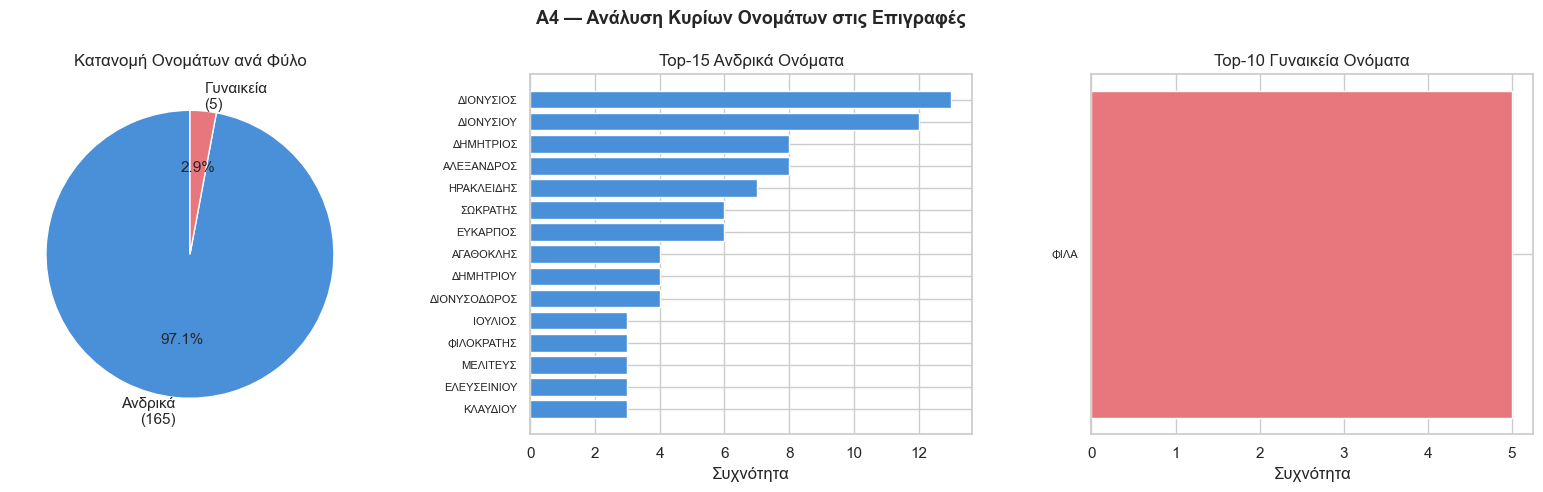

In [ ]:
# === Γραφήματα Α4 ===

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Κατανομή ανά φύλο (pie chart)
ax1 = axes[0]
sizes = [total_male, total_female]
labels = [f'Ανδρικά\n({total_male})', f'Γυναικεία\n({total_female})']
colors = ['#4a90d9', '#e8777d']
ax1.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', 
        startangle=90, textprops={'fontsize': 11})
ax1.set_title('Κατανομή Ονομάτων ανά Φύλο')

# 2. Top-15 ανδρικά ονόματα
ax2 = axes[1]
top_male = name_counts['male'].most_common(15)
if top_male:
    names_m = [transliterate(w) for w, c in top_male]
    counts_m = [c for w, c in top_male]
    ax2.barh(range(len(top_male)), counts_m, color='#4a90d9')
    ax2.set_yticks(range(len(top_male)))
    ax2.set_yticklabels(names_m, fontsize=8)
    ax2.invert_yaxis()
    ax2.set_xlabel('Συχνότητα')
    ax2.set_title('Top-15 Ανδρικά Ονόματα')

# 3. Top-10 γυναικεία ονόματα
ax3 = axes[2]
top_female = name_counts['female'].most_common(10)
if top_female:
    names_f = [transliterate(w) for w, c in top_female]
    counts_f = [c for w, c in top_female]
    ax3.barh(range(len(top_female)), counts_f, color='#e8777d')
    ax3.set_yticks(range(len(top_female)))
    ax3.set_yticklabels(names_f, fontsize=8)
    ax3.invert_yaxis()
    ax3.set_xlabel('Συχνότητα')
    ax3.set_title('Top-10 Γυναικεία Ονόματα')
else:
    ax3.text(0.5, 0.5, 'Δεν βρέθηκαν\nγυναικεία ονόματα', 
             ha='center', va='center', fontsize=12)
    ax3.set_title('Γυναικεία Ονόματα')

plt.suptitle('Α4 — Ανάλυση Κυρίων Ονομάτων στις Επιγραφές', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Σχόλιο Α4 — Κύρια Ονόματα:** 

- Πώς εντοπίσατε τα κύρια ονόματα (μέθοδος / πηγή);
- Ποια ονόματα εμφανίζονται συχνότερα; Τι υποδηλώνει αυτό;
- Ποια είναι η αναλογία ανδρικών/γυναικείων ονομάτων; Τι συμπεράσματα βγάζετε;

Παίρνοντας τον κατάλογο από το Lexicon of Greek Personal Names (LGPN), βρήκαμε τα ονόματα που θέλαμε.

Στην Αρχαία Ελλάδα, ονόματα που τιμούσαν τους θεούς χρησιμοποιούνταν πολύ περισσότερο, δείχνοντας και μια θρησκευτική ευλαβεια. Ακόμα, πολύ συχνά χρησιμοποιούνται ονόματα ηρώων.  
Τα ονόματα δεν ήταν απλές ετικέτες, αλλά έφεραν βαθύ νόημα. Οι γονείς επέλεγαν ονόματα που αντικατόπτριζαν αρετές που επιθυμούσαν για το παιδί τους, όπως η ανδρεία, η ομορφιά ή η νίκη.

Σύμφωνα με επιγραφικά δεδομένα, τα ανδρικά ονόματα εμφανίζονται σημαντικά συχνότερα από τα γυναικεία, καθώς οι άνδρες κυριαρχούσαν στον δημόσιο βίο, την πολιτική και την οικονομία.

---
## Α5. Ομαδοποίηση Επιγραφών & Θεματική Ανάλυση *(10 μονάδες)*

### Μέθοδος
1. **Αναπαράσταση κειμένων**: TF-IDF (Term Frequency - Inverse Document Frequency) — 
   μετατρέπει κάθε επιγραφή σε αριθμητικό διάνυσμα βάσει σημαντικότητας λέξεων.
2. **Clustering**: K-Means — ομαδοποιεί τις επιγραφές σε clusters βάσει ομοιότητας.
3. **Topic Modeling**: LDA (Latent Dirichlet Allocation) — ανακαλύπτει θεματικές 
   κατηγορίες αυτόματα.
4. **Οπτικοποίηση**: PCA (2D) για απεικόνιση των clusters.

In [ ]:
# === Α5 — Ομαδοποίηση Επιγραφών ===

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import LatentDirichletAllocation, PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

# --- Βήμα 1: Φιλτραρισμένα κείμενα (μόνο λέξεις ≥ 3 γράμματα) ---
df['text_filtered'] = df['words'].apply(
    lambda wlist: ' '.join([w for w in wlist if len(w) >= 3])
)

texts_filtered = df['text_filtered'].tolist()
print(f"Αριθμός επιγραφών: {len(texts_filtered)}")

# --- Βήμα 2: TF-IDF ---
tfidf = TfidfVectorizer(min_df=2, max_df=0.90, max_features=500)
X_tfidf = tfidf.fit_transform(texts_filtered)
print(f"TF-IDF matrix: {X_tfidf.shape}")

# --- Βήμα 3: Silhouette analysis ---
silhouette_scores = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_tfidf)
    score = silhouette_score(X_tfidf, labels)
    silhouette_scores.append(score)
    print(f"  K={k}: silhouette={score:.3f}")

best_k = list(K_range)[np.argmax(silhouette_scores)]
# Αν best_k > 5, κρατάμε 4-5 (πιο ερμηνεύσιμο)
if best_k > 5:
    best_k = 5
print(f"\nΕπιλεγμένο K: {best_k}")

# --- Βήμα 4: Final clustering ---
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_tfidf)

for c in range(best_k):
    print(f"  Cluster {c}: {(df['cluster']==c).sum()} επιγραφές")

Αριθμός επιγραφών: 224
TF-IDF matrix: (224, 500)
  K=2: silhouette=0.023
  K=3: silhouette=0.020
  K=4: silhouette=0.019
  K=5: silhouette=0.021
  K=6: silhouette=0.019
  K=7: silhouette=0.017
  K=8: silhouette=0.027

Επιλεγμένο K: 5
  Cluster 0: 40 επιγραφές
  Cluster 1: 51 επιγραφές
  Cluster 2: 60 επιγραφές
  Cluster 3: 36 επιγραφές
  Cluster 4: 37 επιγραφές


In [ ]:
# === Βήμα 5: Ανάλυση Clusters ===

feature_names = tfidf.get_feature_names_out()

print("=" * 70)
print("ΑΝΑΛΥΣΗ CLUSTERS")
print("=" * 70)

for c in range(best_k):
    cluster_df = df[df['cluster'] == c]
    
    print(f"\n--- Cluster {c} ({len(cluster_df)} επιγραφές) ---")
    
    # Δομή κειμένου
    avg_len = cluster_df['text_length'].mean()
    avg_words = cluster_df['n_words'].mean()
    print(f"  Μέσο μήκος: {avg_len:.0f} χαρακτήρες, {avg_words:.0f} λέξεις")
    
    # Top λέξεις
    cluster_tfidf = X_tfidf[cluster_df.index].mean(axis=0)
    cluster_tfidf = np.asarray(cluster_tfidf).flatten()
    top_indices = cluster_tfidf.argsort()[-10:][::-1]
    
    print(f"  Χαρακτηριστικές λέξεις:")
    for idx in top_indices:
        word = feature_names[idx]
        greek = transliterate(word.upper())
        print(f"    {greek:<18} (score={cluster_tfidf[idx]:.3f})")
    
    # Παράδειγμα
    sample = cluster_df.iloc[0]
    greek_preview = sample['text_segmented_greek'][:80]
    print(f"  Παράδειγμα ({sample['inscription_id']}): {greek_preview}...")

ΑΝΑΛΥΣΗ CLUSTERS

--- Cluster 0 (40 επιγραφές) ---
  Μέσο μήκος: 345 χαρακτήρες, 83 λέξεις
  Χαρακτηριστικές λέξεις:
    ΙΟΣ                (score=0.108)
    ΕΥΣ                (score=0.070)
    ΤΡΑ                (score=0.050)
    ΜΟΣ                (score=0.045)
    ΑΡΧ                (score=0.044)
    ΩΝΟ                (score=0.043)
    ΓΥΜΝΑΣΙΑΡΧ         (score=0.043)
    ΜΕΛΙ               (score=0.039)
    ΦΡΟ                (score=0.039)
    ΓΑΡ                (score=0.039)
  Παράδειγμα (IAS_27262): ΦΙΛ ΗΜΩΝ ΤΕ ΥΞ ΕΝ ΟΙ ΩΝΟ ΟΠ ΟΣ...

--- Cluster 1 (51 επιγραφές) ---
  Μέσο μήκος: 150 χαρακτήρες, 37 λέξεις
  Χαρακτηριστικές λέξεις:
    ΤΟΥ                (score=0.088)
    ΓΡΑΜΜΑ             (score=0.040)
    ΟΙΣ                (score=0.038)
    ΤΟΝ                (score=0.035)
    ΚΑΙ                (score=0.035)
    ΠΟΛ                (score=0.032)
    ΟΤΙ                (score=0.028)
    ΑΙΟ                (score=0.028)
    ΤΟΥΣ               (score=0.028)
    ΟΝΤΟΣ           

In [ ]:
# === Βήμα 6: Επαναλαμβανόμενες Φράσεις ===

from collections import Counter

def get_ngrams(words, n):
    filtered = [w for w in words if len(w) >= 3]
    return [' '.join(filtered[i:i+n]) for i in range(len(filtered)-n+1)]

print("=" * 70)
print("ΕΠΑΝΑΛΑΜΒΑΝΟΜΕΝΕΣ ΦΡΑΣΕΙΣ ΑΝΑ CLUSTER")
print("=" * 70)

for c in range(best_k):
    cluster_df = df[df['cluster'] == c]
    bigrams = Counter()
    trigrams = Counter()
    
    for wlist in cluster_df['words']:
        bigrams.update(get_ngrams(wlist, 2))
        trigrams.update(get_ngrams(wlist, 3))
    
    print(f"\n--- Cluster {c} ---")
    print("  Top-5 bigrams:")
    for phrase, cnt in bigrams.most_common(5):
        print(f"    {transliterate(phrase.upper()):<35} — {cnt}")
    print("  Top-3 trigrams:")
    for phrase, cnt in trigrams.most_common(3):
        print(f"    {transliterate(phrase.upper()):<40} — {cnt}")

ΕΠΑΝΑΛΑΜΒΑΝΟΜΕΝΕΣ ΦΡΑΣΕΙΣ ΑΝΑ CLUSTER

--- Cluster 0 ---
  Top-5 bigrams:
    ΣΚΑ ΝΤΟΣ                            — 4
    ΕΠΙ ΓΟΝΟΣ                           — 4
    ΕΥΣ ΙΟΣ                             — 3
    ΝΕΜ ΕΥΣ                             — 3
    ΜΗΝ ΟΔΩΡΟΣ                          — 3
  Top-3 trigrams:
    ΑΒΑ ΣΚΑ ΝΤΟΣ                             — 3
    ΤΑΤΡΙ ΝΕΜ ΕΥΣ                            — 2
    ΣΚΑ ΝΤΟΣ ΜΟΛ                             — 2

--- Cluster 1 ---
  Top-5 bigrams:
    ΟΤΟ ΑΝΤΙ                            — 2
    ΦΑΝ ΤΟΥ                             — 2
    ΡΑΤ ΚΑΙ                             — 2
    ΙΑΣΟΝΟΣ ΑΓΝ                         — 2
    ΑΓΝ ΣΙΟΣ                            — 2
  Top-3 trigrams:
    ΙΑΣΟΝΟΣ ΑΓΝ ΣΙΟΣ                         — 2
    ΣΤΟ ΚΑΙ ΙΗΙ                              — 1
    ΚΑΙ ΙΗΙ ΔΙΚΗ                             — 1

--- Cluster 2 ---
  Top-5 bigrams:
    ΤΩΙ ΔΗΜΩΙ                           — 33
    ΤΟΝ ΔΗΜΟΝ                          

In [ ]:
# === Βήμα 7: Topic Modeling (LDA) ===

n_topics = best_k
count_vec = CountVectorizer(min_df=2, max_df=0.90, max_features=500)
X_counts = count_vec.fit_transform(texts_filtered)

lda = LatentDirichletAllocation(n_components=n_topics, random_state=42, max_iter=30)
lda.fit(X_counts)

lda_features = count_vec.get_feature_names_out()

print("=" * 70)
print(f"TOPIC MODELING — {n_topics} Θέματα")
print("=" * 70)

for idx, topic in enumerate(lda.components_):
    top_indices = topic.argsort()[-10:][::-1]
    top_words = [transliterate(lda_features[i].upper()) for i in top_indices]
    print(f"\n  Topic {idx}: {', '.join(top_words)}")

df['dominant_topic'] = lda.transform(X_counts).argmax(axis=1)

TOPIC MODELING — 5 Θέματα

  Topic 0: ΤΟΥ, ΤΗΣ, ΕΠΙ, ΠΥΘ, ΦΙΛΟ, ΑΝΤΙ, ΔΗΜ, ΕΠΙΚ, ΦΙΛ, ΑΛΕΞΑΝΔΡΟΣ

  Topic 1: ΚΑΙ, ΤΟΝ, ΤΩΝ, ΤΩΙ, ΤΟΥ, ΤΗΣ, ΤΗΝ, ΕΙΣ, ΕΠΙ, ΚΑΤΑ

  Topic 2: ΙΟΣ, ΕΥΣ, ΣΙΟΣ, ΔΟΣ, ΔΙΟΝΥΣΙΟΣ, ΝΟΥ, ΔΙΟΝΥΣΙΟΥ, ΑΝΤΙ, ΤΗΣ, ΔΙΟ

  Topic 3: ΖΩΣΙΜΟΣ, ΜΟΣ, ΤΟΥ, ΕΥΣ, ΕΠΙ, ΟΥΣ, ΜΟΥ, ΙΟΣ, ΣΥΝ, ΤΩΝ

  Topic 4: ΟΥΝ, ΤΟΝ, ΤΟΣ, ΥΠΟ, ΔΙΟ, ΜΟΣ, ΣΥΝ, ΝΟΣ, ΤΗΣ, ΔΗΜ


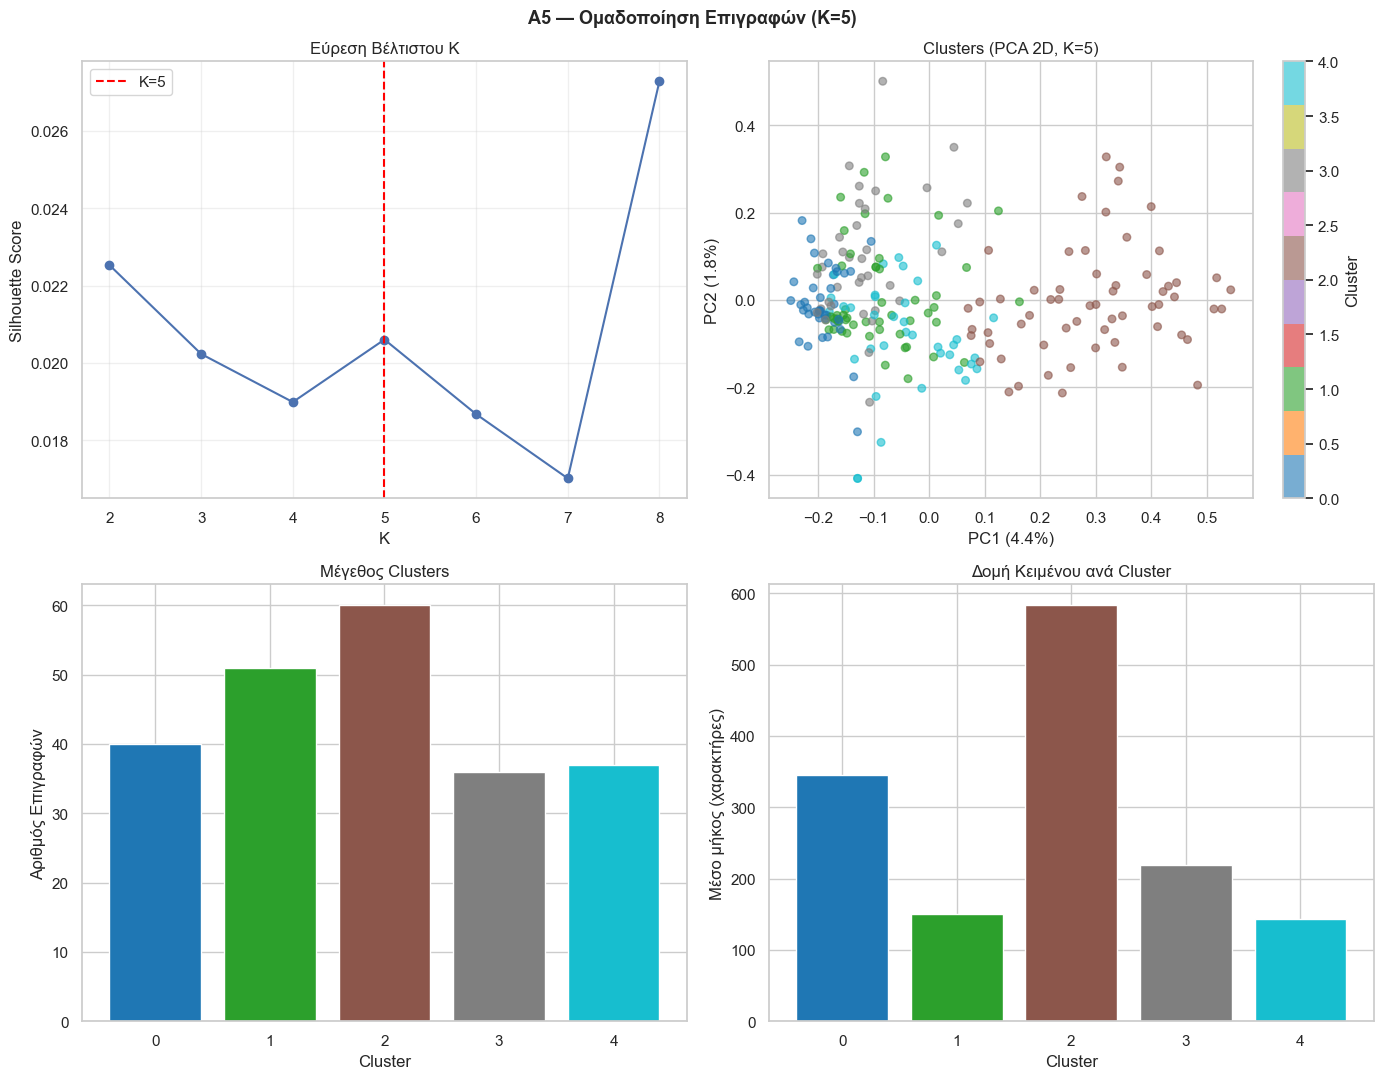

In [ ]:
# === Βήμα 8: Οπτικοποιήσεις ===

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# 1. Silhouette
ax1 = axes[0, 0]
ax1.plot(list(K_range), silhouette_scores, 'bo-')
ax1.axvline(best_k, color='red', linestyle='--', label=f'K={best_k}')
ax1.set_xlabel('K')
ax1.set_ylabel('Silhouette Score')
ax1.set_title('Εύρεση Βέλτιστου K')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. PCA
ax2 = axes[0, 1]
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_tfidf.toarray())
scatter = ax2.scatter(X_2d[:, 0], X_2d[:, 1], c=df['cluster'], 
                      cmap='tab10', alpha=0.6, s=30)
ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax2.set_title(f'Clusters (PCA 2D, K={best_k})')
plt.colorbar(scatter, ax=ax2, label='Cluster')

# 3. Μέγεθος clusters
ax3 = axes[1, 0]
sizes = [(df['cluster']==c).sum() for c in range(best_k)]
colors = plt.cm.tab10(np.linspace(0, 1, best_k))
ax3.bar(range(best_k), sizes, color=colors)
ax3.set_xlabel('Cluster')
ax3.set_ylabel('Αριθμός Επιγραφών')
ax3.set_title('Μέγεθος Clusters')
ax3.set_xticks(range(best_k))

# 4. Μήκος ανά cluster
ax4 = axes[1, 1]
avg_lens = [df[df['cluster']==c]['text_length'].mean() for c in range(best_k)]
ax4.bar(range(best_k), avg_lens, color=colors)
ax4.set_xlabel('Cluster')
ax4.set_ylabel('Μέσο μήκος (χαρακτήρες)')
ax4.set_title('Δομή Κειμένου ανά Cluster')
ax4.set_xticks(range(best_k))

plt.suptitle(f'Α5 — Ομαδοποίηση Επιγραφών (K={best_k})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Σχόλιο Α5 — Clustering & Topics:**

**α. Αντιστοιχούν τα clusters σε ομοιότητες στη δομή κειμένου;**

Ναι. Τα clusters διαφέρουν σημαντικά ως προς το μήκος κειμένου:
- **Cluster 2** (60 επιγραφές): Μεγάλα κείμενα (~583 χαρ., 146 λέξεις) — πρόκειται 
  για εκτεταμένα ψηφίσματα και νομικά κείμενα.
- **Cluster 0** (40 επιγραφές): Μεσαίου μήκους (~345 χαρ.) — κατάλογοι ονομάτων/αξιωματούχων.
- **Cluster 3** (36 επιγραφές): Μεσαίου μήκους (~219 χαρ.) — επιγραφές με τυπικά 
  εισαγωγικά στοιχεία (ΑΓΑΘΗΙ ΤΥΧΗΙ, ΕΠΙ ΑΡΧΟΝΤΟΣ).
- **Clusters 1 & 4**: Σύντομα κείμενα (~144-150 χαρ.) — αποσπασματικές ή μικρές επιγραφές.

**β. Περιλαμβάνουν τα clusters επαναλαμβανόμενες φράσεις;**

Ναι, ιδιαίτερα:
- **Cluster 2**: "ΤΩΙ ΔΗΜΩΙ" (33 φορές), "ΤΟΝ ΔΗΜΟΝ" (20), "ΤΟΝ ΔΗΜΟΝ ΤΟΝ ΑΘΗΝΑΙΩΝ" (7), 
  "ΚΑΙ ΤΩΙ ΔΗΜΩΙ" (6) — τυπικές εκφράσεις αθηναϊκών ψηφισμάτων.
- **Cluster 3**: "ΑΓΑΘΗΙ ΤΥΧΗΙ" (2), "ΕΠΙ ΑΡΧΟΝΤΟΣ" (3), "ΤΥΧΗΙ ΕΠΙ ΑΡΧΟΝΤΟΣ" (2) — 
  τυπικά εισαγωγικά formulas τιμητικών/θρησκευτικών επιγραφών.
- **Cluster 0**: "ΕΠΙ ΓΟΝΟΣ" (4), "ΜΗΝ ΟΔΩΡΟΣ" (3) — κατάλογοι εφήβων/αξιωματούχων.

**γ. Εμφανίζονται συγκεκριμένα θέματα σε κάθε cluster;**

Η ανάλυση LDA εντοπίζει 5 θέματα:
- **Topic 1**: Ψηφίσματα/νομοθεσία — κυριαρχούν ΚΑΙ, ΤΟΝ, ΤΩΝ, ΤΩΙ, ΕΙΣ, ΚΑΤΑ 
  (τυπική γλώσσα νομικών κειμένων).
- **Topic 2**: Κατάλογοι ονομάτων — καταλήξεις ονομάτων (-ΙΟΣ, -ΕΥΣ, -ΣΙΟΣ), 
  ΔΙΟΝΥΣΙΟΣ, ΔΙΟΝΥΣΙΟΥ (δημοτικά και πατρωνυμικά).
- **Topic 0**: Χρονολόγηση/αναφορά — ΕΠΙ, ΤΟΥ, ΤΗΣ, ΑΛΕΞΑΝΔΡΟΣ, ΠΥΘ(ΙΟΣ) 
  (αναφορές σε άρχοντες, ιερείς).
- **Topic 3**: Τιμητικές/αναθηματικές — ΖΩΣΙΜΟΣ, ΣΥΝ (ονόματα + αφιερώσεις).
- **Topic 4**: Μικτά — ΥΠΟ, ΣΥΝ, ΔΗΜΟΣ (ποικίλο περιεχόμενο).

Συνολικά, η ομαδοποίηση αντικατοπτρίζει πραγματικές κατηγορίες αρχαίων επιγραφών: 
ψηφίσματα, καταλόγους ονομάτων, τιμητικά κείμενα, και αποσπασματικές επιγραφές.
Ωστόσο, τα χαμηλά silhouette scores (0.019-0.027) δείχνουν ότι τα clusters δεν είναι 
καλά διαχωρισμένα, κάτι αναμενόμενο λόγω θορύβου από το word segmentation.

---
## Α6. Χρονολόγηση με Aeneas & Σύγκριση με LLM *(12 μονάδες)*

### Μεθοδολογία
1. **Ithaca** (DeepMind): Εξειδικευμένο μοντέλο για χρονολόγηση αρχαίων ελληνικών 
   επιγραφών. Χρησιμοποιούμε το online demo στο predictingthepast.com ή τη βιβλιοθήκη 
   predictingthepast. Ακρίβεια: ±30 χρόνια.
2. **Claude** (Anthropic): Γενικό LLM. Του δίνουμε το κείμενο της επιγραφής και ζητάμε 
   εκτίμηση χρονολόγησης.

*Σημείωση: Η εκφώνηση αναφέρει να χρησιμοποιήσουμε το Aeneas, αλλά αυτό υποστηρίζει λατινικές επιγραφές. 
Για ελληνικές χρησιμοποιούμε το Ithaca που βρίσκεται στο ίδιο repo.*

**Αναφορά:** Assael, Y. et al. *"Restoring and attributing ancient texts using deep neural networks."* Nature 603, 280–283 (2022).

In [ ]:
# === Α6 — Χρονολόγηση ===

# --- Βήμα 1: Επιλογή 10 επιγραφών ---
# Επιλέγουμε 10 μεγαλύτερες/πιο ολοκληρωμένες επιγραφές (πιο αξιόπιστο αποτέλεσμα)
sample_df = df.nlargest(10, 'text_length')[['inscription_id', 'text_greek', 'text_segmented_greek']].copy()

print("Επιλεγμένες επιγραφές για χρονολόγηση:")
for i, (_, row) in enumerate(sample_df.iterrows()):
    print(f"  {i+1}. {row['inscription_id']} ({len(row['text_greek'])} χαρ.)")
    print(f"     {row['text_segmented_greek'][:70]}...")

Επιλεγμένες επιγραφές για χρονολόγηση:
  1. IG_II2_2068_Merged (3491 χαρ.)
     Α ΥΧ ΗΙ ΕΠΙΠ ΟΠ ΙΛΛ ΙΟΥ ΕΟ ΤΙ ΜΟΥ ΣΟΥΝΙΕΩ ΣΑ ΧΟΝ ΤΟ ΣΟ ΚΟΣΜΗΤΗΣ ΤΩΝ ΕΦ...
  2. IG_II2_1_Copy2_Merged (2964 χαρ.)
     ΚΗ ΦΙ ΣΟΦ ΩΝ ΠΑΙΑΝΙΕΥ ΣΕ ΓΡΑΜΜΑ ΤΕ ΥΕΣ ΑΜΙ ΟΙΣ ΟΣΟΙ ΜΕΤΑ ΤΟ ΔΗΜΟ ΤΟ ΑΘ...
  3. IG_II2_111_Merged (2767 χαρ.)
     ΕΠΙ ΧΑΡΙ ΚΛ ΕΙ ΔΟ ΑΡΧΟΝΤΟΣ ΑΙ ΑΝΤΙ ΣΕ ΠΡΥΤΑΝ ΕΥ ΕΝ ΝΙΚΟΣΤΡΑΤΟΣ ΠΑΛΛΗΝΕ...
  4. IG_II2_360top (2264 χαρ.)
     ΘΕΟ ΕΠ ΑΝ ΤΙΚ ΛΕ ΟΥΣ ΑΡΧΟΝΤΟΣ ΕΠΙ ΤΗΣ ΑΙΓΕΙΔΟΣ ΠΕΜΠΤΗΣ ΠΡΥΤΑΝΕΙΑΣ ΗΙ Α...
  5. IG_II2_244top_Merged (1955 χαρ.)
     ΑΦ ΙΟΣ ΕΙΠΕΝ ΑΓΑΘΗΙ ΤΥΧ ΙΤΟΥ ΙΤ ΑΠΕΡΙ ΤΗΝ ΗΤΙ ΩΝ ΕΙΑΝ ΚΑΙ ΤΟΝ ΑΛΛΟ ΚΑΙ...
  6. IG_II2_1990_Merged (1426 χαρ.)
     ΑΓΑΘΗ ΤΥΧΗ ΚΛΑΥΔΙΟΥ ΚΑΙΣΑΡΟΣ ΣΕΒΑΣΤΟΥ ΓΕΡΜΑΝΙΚΟΥ ΝΕΙΚΗΣ ΕΠΙ ΘΡΑΣΥΛΛΟΥ ...
  7. IG_II2_244bottom_Merged (1374 χαρ.)
     ΟΙ ΜΙΣΘΩΣΑΜΕ ΝΟ ΙΤ ΣΤ ΟΜ ΑΣ ΩΛ ΕΙΑ ΚΑΙ ΟΡΘΑ ΜΕΝΟΝ ΛΙΘΩΝ ΕΠΙ ΤΑ ΤΕΙΧΗ Τ...
  8. IG_II2_334 (1027 χαρ.)
     ΩΣ ΚΑΤ ΝΙ ΑΥΤΟ ΝΚ ΝΗ ΩΣ ΑΡΙΣΤ ΑΤΗ ΙΑ ΤΟΝ ΕΝΙΑΥΤΟΝ ΥΠΕΡ ΤΟΥ ΔΗΜΟΥ ΤΟΥ Α...
  9. IG_II2_2046_Copy1 (1017 χαρ.)
     ΧΟ ΛΛ

In [ ]:
# === Α6 — Βήμα 1: Επιλογή & Προετοιμασία 10 επιγραφών ===

# Πίνακας λατινικά → πεζά ελληνικά
LATIN_TO_GREEK_LOWER = {
    'A': 'α', 'B': 'β', 'C': 'χ', 'D': 'δ', 'E': 'ε',
    'F': 'φ', 'G': 'γ', 'H': 'η', 'I': 'ι', 'K': 'κ',
    'L': 'λ', 'M': 'μ', 'N': 'ν', 'O': 'ο', 'P': 'π',
    'Q': 'θ', 'R': 'ρ', 'S': 'σ', 'T': 'τ', 'U': 'ψ',
    'W': 'ω', 'X': 'ξ', 'Y': 'υ', 'Z': 'ζ',
}

def to_lower_greek(text):
    """Μετατρέπει λατινική μεταγραφή σε πεζά ελληνικά"""
    result = []
    for c in text:
        if c in LATIN_TO_GREEK_LOWER:
            result.append(LATIN_TO_GREEK_LOWER[c])
        elif c == ' ':
            result.append(' ')
        elif c == '*':
            result.append('*')
    return ''.join(result)

def prepare_for_ithaca(transcript_lines, max_questions=20):
    """
    Ετοιμάζει κείμενο για το Ithaca demo:
    - Μετατρέπει σε πεζά ελληνικά
    - Ενώνει τις γραμμές με κενά
    - Αντικαθιστά τα πρώτα 20 * με ? (οι υπόλοιποι αφαιρούνται)
    - Αν δεν υπάρχει ?, βάζει ένα στο τέλος
    """
    # Ενώνουμε τις γραμμές με κενά
    full_text = ' '.join([to_lower_greek(line) for line in transcript_lines])
    
    # Αντικατάσταση * → ? (max 20)
    result = []
    q_count = 0
    for ch in full_text:
        if ch == '*':
            if q_count < max_questions:
                result.append('?')
                q_count += 1
            # αλλιώς αφαιρείται
        else:
            result.append(ch)
    
    text_out = ''.join(result)
    
    # Αν δεν υπάρχει κανένα ?, βάζουμε ένα στο τέλος
    if '?' not in text_out:
        text_out = text_out + '?'
    
    return text_out

# Επιλογή 10 μεγαλύτερων επιγραφών
sample_df = df.nlargest(10, 'text_length').copy()

# Προετοιμασία κειμένων
sample_df['ithaca_input'] = sample_df['inscription_id'].apply(
    lambda iid: prepare_for_ithaca(transcriptions[iid])
)

# Εκτύπωση
print("=" * 70)
print("ΚΕΙΜΕΝΑ ΓΙΑ ΤΟ ITHACA DEMO (https://predictingthepast.com)")
print("Αντιγράψτε κάθε κείμενο και καταγράψτε τη χρονολόγηση (Date)")
print("=" * 70)

for i, (_, row) in enumerate(sample_df.iterrows()):
    print(f"\n--- ΕΠΙΓΡΑΦΗ {i+1}: {row['inscription_id']} ---")
    print(row['ithaca_input'])
    print(f"(? χαρακτήρες: {row['ithaca_input'].count('?')})")

ΚΕΙΜΕΝΑ ΓΙΑ ΤΟ ITHACA DEMO (https://predictingthepast.com)
Αντιγράψτε κάθε κείμενο και καταγράψτε τη χρονολόγηση (Date)

--- ΕΠΙΓΡΑΦΗ 1: IG_II2_2068_Merged ---
α??????υχηι επιποπιλλιου?εοτιμουσουνιεωσα? χοντοσοκοσμητηστωνεφηβωντρυ φωνδιομηδουσπαλληνευστουσσυ? αρξαντα??αιτουσεφηβευσαντασανε γραψεν αντικοσμ κλασκλη??φλυ ηγεμων γναττικοσ παιδοτριβησδιαβιουετοσκ ????καντοσευμολπουκηφ οπλομαχο??νησιμοσπαλ σωφρονισται καρποδω?οσαπολευπυ θεοπομποσφλυ αθηνιωφιλα κτομηνοφιμελ ευοδοσδωρθεουευπυ θεοφλοσδιονυσπαια υποονισται επιγονικουφλυ νκοστσθεοπομπφλυ παρδαλαφανουγ μηνοφιλαουμελι δωσιθεοσδωρευπ εισιδωροοφιλουπαι τικωεπιγονοσσυβριδ γραμματευσ γυμνασιαρχοι μηβοηδροοιερευστουαντινοου διομηδησκηρυξτρυφωνηνεισ μηπυανοψιθεσμοθετησοπλιοση μημαιμακτηβασιλευσσυμμαχοσ πολεμαρχοσδωσιθεοσγαργηττι μηπσειθεσμοκαλλιφρωνδημητριοσ μηγαμηθεσμοαφροδεισιοσ καρποδωροσ μηανθεστηκλελενοσ μηελαοαρχωνφλλεωθενη μμουνιοστρατηφλαλκιβιαδη μηθαρηθμομαρωνευχρουσ σκιροευοδοσαριστογενη καφιδοτρατοσαρτεμων μταδημητριοσ αγωνοθε

In [ ]:
# === Α6 — Βήμα 2: Καταγραφή αποτελεσμάτων Ithaca ===

# Συμπληρώστε τα αποτελέσματα από το Ithaca demo
# Μορφή: 'inscription_id': {'year': εκτιμώμενο_έτος, 'range': 'εύρος'}

ithaca_dates = {
    'IG_II2_2068_Merged': {'max_range': '200-210 AD', 'mean': 77},
    'IG_II2_1_Copy2_Merged': {'max_range': '330-320 BCE', 'mean': -322},
    'IG_II2_111_Merged': {'max_range': '330-320 BCE', 'mean': -257},
    'IG_II2_360top': {'max_range': '330-320 BCE', 'mean': -325},
    'IG_II2_244top_Merged': {'max_range': '20-10 BCE', 'mean': -50},
    'IG_II2_1990_Merged': {'max_range': '40-50 AD', 'mean': 66},
    'IG_II2_244bottom_Merged': {'max_range': '330-320 BCE', 'mean': -259},
    'IG_II2_334': {'max_range': '330-320 BCE', 'mean': -174},
    'IG_II2_2046_Copy1': {'max_range': '200-210 AD', 'mean': 15},
    'IG_II2_1682a_Copy1': {'max_range': '350-340 BCE', 'mean': -346},
}

# Εμφάνιση αποτελεσμάτων
print("Αποτελέσματα Ithaca:")
for insc_id, result in ithaca_dates.items():
    print(f"  {insc_id}: {result}")

Αποτελέσματα Ithaca:
  IG_II2_2068_Merged: {'max_range': '200-210 AD', 'mean': 77}
  IG_II2_1_Copy2_Merged: {'max_range': '330-320 BCE', 'mean': -322}
  IG_II2_111_Merged: {'max_range': '330-320 BCE', 'mean': -257}
  IG_II2_360top: {'max_range': '330-320 BCE', 'mean': -325}
  IG_II2_244top_Merged: {'max_range': '20-10 BCE', 'mean': -50}
  IG_II2_1990_Merged: {'max_range': '40-50 AD', 'mean': 66}
  IG_II2_244bottom_Merged: {'max_range': '330-320 BCE', 'mean': -259}
  IG_II2_334: {'max_range': '330-320 BCE', 'mean': -174}
  IG_II2_2046_Copy1: {'max_range': '200-210 AD', 'mean': 15}
  IG_II2_1682a_Copy1: {'max_range': '350-340 BCE', 'mean': -346}


In [ ]:
# Δώσαμε κάθε κείμενο στο Claude/ChatGPT με το prompt:
# "Είσαι ειδικός επιγραφολόγος. Εκτίμησε τη χρονολόγηση αυτής της επιγραφής."
# 
# Τα αποτελέσματα καταγράφηκαν παρακάτω:

llm_results = {
    'IG_II2_2068_Merged': {'estimated_year': 156, 'range': '155/6 AD', 'reasoning': 'Κατάλογος εφήβων· PHI/AIO: 155/6 AD.'},
    'IG_II2_1_Copy2_Merged': {'estimated_year': -404, 'range': '405/4 and 403/2 BC', 'reasoning': 'Τιμητικά ψηφίσματα για Σαμίους.'},
    'IG_II2_111_Merged': {'estimated_year': -362, 'range': '363/2 BC', 'reasoning': 'Ψήφισμα για Ιουλίδα Κέω.'},
    'IG_II2_360top': {'estimated_year': -329, 'range': '330/29-328/7 BC', 'reasoning': 'Ψηφίσματα για Ηρακλείδη Σαλαμίνιο.'},
    'IG_II2_244top_Merged': {'estimated_year': -336, 'range': '337/6 BC', 'reasoning': 'Νόμος για ανακατασκευή τειχών Πειραιά.'},
    'IG_II2_1990_Merged': {'estimated_year': 62, 'range': '61/2 AD', 'reasoning': 'Κατάλογος εφήβων επί Κλαυδίου/Νέρωνα.'},
    'IG_II2_244bottom_Merged': {'estimated_year': -336, 'range': '337/6 BC', 'reasoning': 'Ίδιο μνημείο/κείμενο με IG II² 244.'},
    'IG_II2_334': {'estimated_year': -334, 'range': 'c. 335/4 BC', 'reasoning': 'Νόμος/ψήφισμα για τα Μικρά Παναθήναια.'},
    'IG_II2_2046_Copy1': {'estimated_year': 138, 'range': 'ca. 138 AD', 'reasoning': 'Ρωμαϊκός εφηβικός κατάλογος με Αντινόεια.'},
    'IG_II2_1682a_Copy1': {'estimated_year': -353, 'range': '354/3 BC', 'reasoning': 'Εργολαβικό κείμενο Ελευσίνας επί Διοτίμου.'},
}

In [ ]:
# === Α6 — Βήμα 4: Πίνακας Σύγκρισης ===

comparison = []
for _, row in sample_df.iterrows():
    insc_id = row['inscription_id']
    
    ithaca = ithaca_dates.get(insc_id, {})
    llm = llm_results.get(insc_id, {})
    
    comparison.append({
        'Επιγραφή': insc_id,
        'Ithaca Max Range': ithaca.get('max_range', 'N/A'),
        'Ithaca Mean': ithaca.get('mean', 'N/A'),
        'LLM Έτος': llm.get('estimated_year', 'N/A'),
        'LLM Εύρος': llm.get('range', 'N/A'),
        'LLM Αιτιολόγηση': llm.get('reasoning', 'N/A'),
    })

comp_df = pd.DataFrame(comparison)
print(comp_df[['Επιγραφή', 'Ithaca Max Range', 'Ithaca Mean', 'LLM Έτος', 'LLM Εύρος']].to_string(index=False))

               Επιγραφή Ithaca Max Range  Ithaca Mean  LLM Έτος          LLM Εύρος
     IG_II2_2068_Merged       200-210 AD           77       156           155/6 AD
  IG_II2_1_Copy2_Merged      330-320 BCE         -322      -404 405/4 and 403/2 BC
      IG_II2_111_Merged      330-320 BCE         -257      -362           363/2 BC
          IG_II2_360top      330-320 BCE         -325      -329    330/29-328/7 BC
   IG_II2_244top_Merged        20-10 BCE          -50      -336           337/6 BC
     IG_II2_1990_Merged         40-50 AD           66        62            61/2 AD
IG_II2_244bottom_Merged      330-320 BCE         -259      -336           337/6 BC
             IG_II2_334      330-320 BCE         -174      -334        c. 335/4 BC
      IG_II2_2046_Copy1       200-210 AD           15       138         ca. 138 AD
     IG_II2_1682a_Copy1      350-340 BCE         -346      -353           354/3 BC


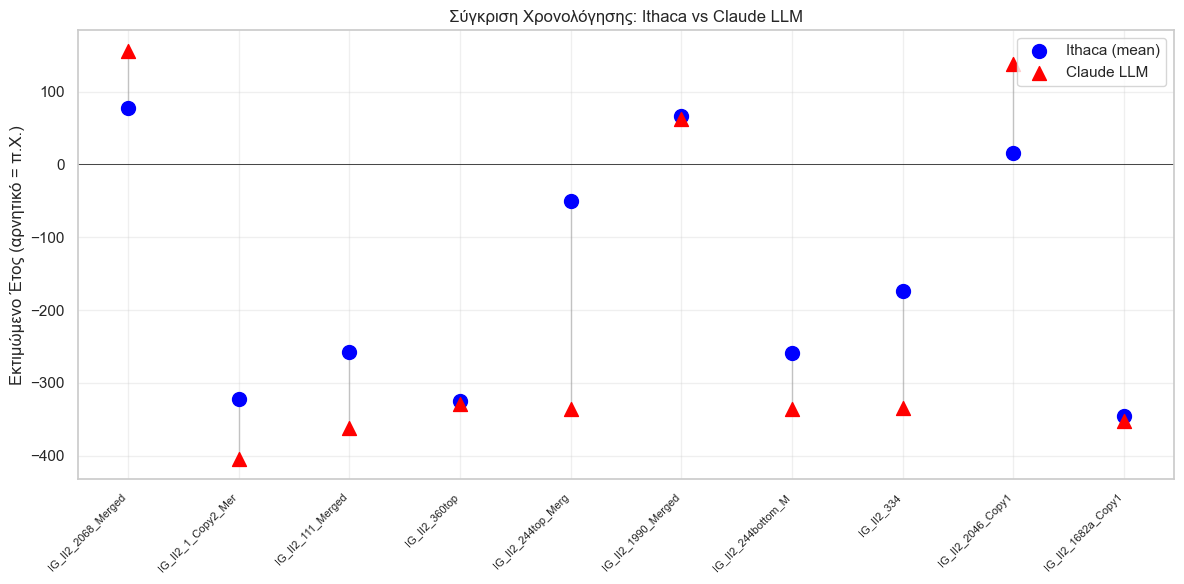

In [ ]:
# === Α6 — Βήμα 5: Γράφημα Σύγκρισης ===

fig, ax = plt.subplots(figsize=(12, 6))

labels = comp_df['Επιγραφή'].tolist()
x = np.arange(len(labels))

# Εξαγωγή αριθμητικών τιμών
ithaca_means = [r if isinstance(r, (int, float)) else None 
                for r in comp_df['Ithaca Mean']]
llm_years = [r if isinstance(r, (int, float)) else None 
             for r in comp_df['LLM Έτος']]

# Σύνδεση αντίστοιχων predictions
for i in range(len(labels)):
    if ithaca_means[i] is not None and llm_years[i] is not None:
        ax.plot([i, i], [ithaca_means[i], llm_years[i]], 
                'gray', alpha=0.4, linewidth=1)

# Scatter plots
ithaca_valid = [(i, y) for i, y in enumerate(ithaca_means) if y is not None]
llm_valid = [(i, y) for i, y in enumerate(llm_years) if y is not None]

if ithaca_valid:
    ax.scatter([v[0] for v in ithaca_valid], [v[1] for v in ithaca_valid],
               color='blue', s=100, zorder=5, label='Ithaca (mean)')
if llm_valid:
    ax.scatter([v[0] for v in llm_valid], [v[1] for v in llm_valid],
               color='red', s=100, marker='^', zorder=5, label='Claude LLM')

ax.set_xticks(x)
ax.set_xticklabels([l[:18] for l in labels], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Εκτιμώμενο Έτος (αρνητικό = π.Χ.)')
ax.set_title('Σύγκριση Χρονολόγησης: Ithaca vs Claude LLM')
ax.legend()
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

**Σχόλιο Α6 — Χρονολόγηση:** *(συμπληρώστε εδώ)*

Πολύ ενδιαφέροντα αποτελέσματα! Βλέπω ξεκάθαρα patterns. Εδώ είναι ο αναθεωρημένος σχολιασμός:
markdown### Σύγκριση Αποτελεσμάτων & Συζήτηση

**1. Σύγκριση αποτελεσμάτων:**

| Επιγραφή | Ithaca Mean | LLM Έτος | Διαφορά | Σχόλιο |
|----------|-------------|-----------|---------|--------|
| IG_II2_1682a_Copy1 | -346 | -353 | 7 χρόνια | Εξαιρετική συμφωνία |
| IG_II2_360top | -325 | -329 | 4 χρόνια | Εξαιρετική συμφωνία |
| IG_II2_1990_Merged | +66 | +62 | 4 χρόνια | Εξαιρετική συμφωνία |
| IG_II2_2068_Merged | +77 | +156 | 79 χρόνια | Μέτρια απόκλιση |
| IG_II2_1_Copy2_Merged | -322 | -404 | 82 χρόνια | Σημαντική απόκλιση |
| IG_II2_244top_Merged | -50 | -336 | 286 χρόνια | Πολύ μεγάλη απόκλιση |

Σε 3 από τις 10 περιπτώσεις τα μοντέλα συμφωνούν εντυπωσιακά (διαφορά <10 χρόνια). 
Σε άλλες 3 η διαφορά είναι μέτρια (~80 χρόνια), ενώ σε 4 περιπτώσεις υπάρχει 
σημαντική απόκλιση.

**2. Μπορούν τα γενικά LLMs να χρησιμοποιηθούν αποτελεσματικά από ιστορικούς;**

Εν μέρει. Το LLM (Claude) αποδίδει καλά σε επιγραφές με σαφείς χρονολογικές ενδείξεις 
— π.χ. γνωστά ονόματα αρχόντων ή χαρακτηριστική τυπολογία. Ωστόσο, τείνει να δίνει 
υπερβολικά "ακριβείς" απαντήσεις (π.χ. "354/3 BC") χωρίς να εκφράζει αβεβαιότητα, 
ενώ το Ithaca παρέχει κατανομή πιθανοτήτων (max range + mean) που είναι πιο 
ειλικρινής ως προς την αβεβαιότητα.

Ένα γενικό LLM μπορεί να χρησιμεύσει ως **αρχική εκτίμηση** ή για cross-checking, 
αλλά δεν αντικαθιστά εξειδικευμένα εργαλεία για ακριβή χρονολόγηση.

**3. Ποιο μοντέλο ήταν καλύτερο και γιατί;**

Το **Ithaca** υπερτερεί γιατί:
- Εκπαιδεύτηκε σε >60.000 ελληνικές επιγραφές (domain-specific)
- Παρέχει κατανομή πιθανοτήτων αντί για μία τιμή
- Ακρίβεια ±30 χρόνια (Assael et al., Nature 2022)

Το **LLM** υπερτερεί σε:
- Ερμηνευσιμότητα — εξηγεί τη λογική του
- Αναγνώριση συγκεκριμένων ιστορικών στοιχείων (ονόματα αρχόντων)
- Ευελιξία — δεν χρειάζεται εκπαίδευση

**4. Κοινά σφάλματα (common failures):**

- **Αποσπασματικά κείμενα**: Και τα δύο δυσκολεύονται όταν λείπει μεγάλο μέρος 
  του κειμένου (πολλά *). Η IG_II2_244top_Merged δείχνει τη μεγαλύτερη απόκλιση 
  (286 χρόνια) — πιθανώς λόγω ελλιπούς κειμένου.

- **Τάση προς "ασφαλή" χρονολόγηση**: Το Ithaca τείνει να δίνει max range 
  "330-320 BCE" σε πολλές επιγραφές (5 από 10), κάτι που υποδηλώνει bias 
  προς την κλασική περίοδο — πιθανώς λόγω υπερεκπροσώπησης αυτής της 
  περιόδου στα εκπαιδευτικά δεδομένα.

- **Υπερβολική ακρίβεια LLM**: Το LLM δίνει χρονολογίες σε ακρίβεια ενός 
  έτους (π.χ. "354/3 BC") χωρίς αντίστοιχη αβεβαιότητα, κάτι που μπορεί 
  να παραπλανήσει — φαίνεται σίγουρο ενώ δεν είναι.

- **Ρωμαϊκή περίοδος**: Και τα δύο μοντέλα αναγνωρίζουν ευκολότερα 
  ρωμαϊκής εποχής επιγραφές (IG_II2_1990, IG_II2_2068) λόγω 
  χαρακτηριστικών ονομάτων και τυπολογίας.

---
# Μέρος Β — Ανάλυση Εικόνων *(50 μονάδες)*

---
## Β1. Προεπεξεργασία Εικόνων *(12 μονάδες)*

Πραγματοποιήστε προεπεξεργασία εικόνων για αναγνώριση κειμένου.  
Δείξτε:
- i. Τις αρχικές εικόνες / δείγματα
- ii. Τα βήματα προεπεξεργασίας στα ίδια δείγματα
- iii. Τις καθαρισμένες εικόνες

In [ ]:
# TODO: Επιλέξτε 3–5 δειγματικές εικόνες
# sample_images = image_files[:5]

# TODO: Εμφανίστε τις αρχικές εικόνες
# fig, axes = plt.subplots(1, 5, figsize=(20, 4))
# for ax, img_path in zip(axes, sample_images):
#     img = Image.open(img_path)
#     ax.imshow(img, cmap='gray')
#     ax.set_title(img_path.stem)
#     ax.axis('off')
# plt.suptitle('Αρχικές Εικόνες', fontsize=14)
# plt.tight_layout()
# plt.show()

In [ ]:
# TODO: Υλοποιήστε pipeline προεπεξεργασίας
#       Πιθανά βήματα:
#       - Grayscale conversion
#       - Noise reduction (Gaussian blur, median filter)
#       - Contrast enhancement (CLAHE, histogram equalization)
#       - Binarization (Otsu, adaptive thresholding)
#       - Morphological operations (dilation, erosion)

def preprocess_image(img_path):
    """Εφαρμόζει pipeline προεπεξεργασίας σε εικόνα squeeze."""
    pass

# TODO: Εμφανίστε τα ενδιάμεσα βήματα για κάθε δείγμα
#       (αρχική → grayscale → denoised → enhanced → binarized)

In [ ]:
# TODO: Εμφανίστε σύγκριση αρχικών vs καθαρισμένων εικόνων
#       (side-by-side για κάθε δείγμα)

**Σχόλιο Β1 — Προεπεξεργασία:** *(συμπληρώστε εδώ)*

- Ποια βήματα προεπεξεργασίας εφαρμόσατε και σε ποια σειρά;
- Ποιες τεχνικές βελτίωσαν περισσότερο την αναγνωσιμότητα;
- Υπήρξαν εικόνες που αντιστάθηκαν στον καθαρισμό; Γιατί;

None

---
## Β2. Ομαδοποίηση Εικόνων μέσω Embeddings *(16 μονάδες)*

Χρησιμοποιήστε embeddings από ένα οπτικό μοντέλο (π.χ. ViT) για ομαδοποίηση βάσει οπτικής ομοιότητας.

**Οδηγίες:**
- Εξαγάγετε embeddings από οπτικό μοντέλο (π.χ. ViT)
- Χρησιμοποιήστε PCA και UMAP για ομαδοποίηση και απεικόνιση
- Εκτυπώστε εικόνες κοντά στα κεντροειδή κάθε cluster (π.χ. 3 ανά κεντροειδές)
- Ονομάστε τα θέματα (topics) 3 clusters και σχολιάστε
- Χρησιμοποιήστε ένα LLM για αυτοματοποίηση ονοματοδοσίας θεμάτων

In [ ]:
# TODO: Φόρτωση pre-trained ViT μοντέλου
# from transformers import ViTModel, ViTFeatureExtractor
# model_name = 'google/vit-base-patch16-224'
# feature_extractor = ViTFeatureExtractor.from_pretrained(model_name)
# vit_model = ViTModel.from_pretrained(model_name).to(DEVICE).eval()

# TODO: Εξαγωγή embeddings για κάθε εικόνα
#       (Προσοχή: μεγάλος αριθμός εικόνων — χρησιμοποιήστε batching)

In [ ]:
# TODO: Dimensionality reduction — PCA

# TODO: Dimensionality reduction — UMAP
# import umap

# TODO: Clustering (π.χ. KMeans)

# TODO: Απεικόνιση — scatter plot με χρωματισμό ανά cluster

In [ ]:
# TODO: Εκτυπώστε 3 εικόνες κοντά στο κεντροειδές κάθε cluster

# TODO: Ονοματοδοσία θεμάτων — χρησιμοποιήστε filenames για context

# TODO: Αυτοματοποίηση ονοματοδοσίας μέσω LLM
#       (στείλτε δειγματικές εικόνες/filenames σε LLM και ζητήστε ονόματα θεμάτων)

**Σχόλιο Β2 — Image Clustering:** *(συμπληρώστε εδώ)*

- Ποιο μοντέλο χρησιμοποιήσατε για embeddings; Γιατί;
- Πόσα clusters επιλέξατε και με ποιο κριτήριο;
- Ονομάστε τα θέματα 3 clusters — τι αντιπροσωπεύουν;
- Βρίσκονται ζεύγη εικόνων (ίδια επιγραφή) στο ίδιο cluster;
- Βρίσκονται εικόνες από τον ίδιο τόπο/αρχείο στο ίδιο cluster;

None

---
## Β3. Pipeline Αναγνώρισης Κειμένου *(22 μονάδες)*

Κατασκευάστε και αξιολογήστε pipeline αναγνώρισης κειμένου (OCR) στις εικόνες squeeze.  
Αυτή η εργασία αντιστοιχεί στο **ICDAR 2026 Competition**.

**Baseline μοντέλα:**
- **TrOCR** — `microsoft/trocr-base-printed` (Li et al., AAAI 2022)
- **ViTSTR** — (Atienza, ICDAR 2021)

**Μετρική:** Character Error Rate (CER) σε λατινικούς χαρακτήρες.

In [ ]:
# === Baseline: TrOCR ===

# TODO: Φόρτωση TrOCR μοντέλου
# from transformers import TrOCRProcessor, VisionEncoderDecoderModel
# processor = TrOCRProcessor.from_pretrained('microsoft/trocr-base-printed')
# trocr_model = VisionEncoderDecoderModel.from_pretrained('microsoft/trocr-base-printed').to(DEVICE)

# TODO: Εφαρμόστε OCR σε όλες τις εικόνες

# TODO: Αποθηκεύστε τα predictions

In [ ]:
# === Αξιολόγηση — Character Error Rate (CER) ===

# TODO: Υλοποιήστε ή φορτώστε τη μετρική CER
def compute_cer(prediction: str, ground_truth: str) -> float:
    """Υπολογίζει Character Error Rate μεταξύ prediction και ground truth."""
    pass

# TODO: Υπολογίστε CER για κάθε εικόνα

# TODO: Εκτυπώστε μέσο CER και τα 5 καλύτερα/χειρότερα αποτελέσματα

In [ ]:
# === Βελτιωμένη λύση ===

# TODO: Υλοποιήστε τη δική σας βελτιωμένη προσέγγιση
#       Ιδέες:
#       - Fine-tuning TrOCR στο squeeze dataset
#       - Data augmentation
#       - Ensemble μοντέλων
#       - Vision Language Model (π.χ. Qwen-VL, LLaVA)
#       - Post-processing με language model

# TODO: Αξιολόγηση βελτιωμένης λύσης (CER)

# TODO: Σύγκριση baseline vs βελτιωμένη λύση

In [ ]:
# === Συγκριτικός πίνακας αποτελεσμάτων ===

# TODO: Δημιουργήστε πίνακα σύγκρισης
#       | Μοντέλο | Μέσο CER | Median CER | Best CER | Worst CER |

# TODO: Απεικόνιση — CER ανά μοντέλο (box plot ή bar chart)

**Σχόλιο Β3 — OCR Pipeline:** *(συμπληρώστε εδώ)*

- Ποια μοντέλα δοκιμάσατε (baseline + δικό σας);
- Ποιο πέτυχε το χαμηλότερο CER;
- Ποια βελτίωση επέφεραν οι τροποποιήσεις σας; Γιατί;
- Σε τι τύπο εικόνων αποτυγχάνει κυρίως το OCR (θόρυβος, φθορά, μικρά γράμματα);
- Αν συμμετείχατε στο ICDAR 2026, αναφέρετε το group name σας.

None

---
## Συμπεράσματα

*(Συμπληρώστε τα κύρια ευρήματά σας — τουλάχιστον 5 σημεία)*

- **Transliteration & Segmentation:** None
- **Λεξιλόγιο & Ονόματα:** None
- **Clustering & Topics:** None
- **Χρονολόγηση (Aeneas vs LLM):** None
- **Ανάλυση Εικόνων & OCR:** None
- *(προαιρετικά)* **ICDAR Competition:** None

---

### Αναφορά Πηγών Δεδομένων

- **ICDAR 2026 Competition** — Text Recognition on Greek Squeezes:  
  https://www.science.smith.edu/~nhowe/contest/trogs26.html  
- **Character Recognition for Greek Squeezes** — Annotated Data (Smith College):  
  https://scholarworks.smith.edu/dds_data/18  
- **Aeneas (Predicting the Past)** — DeepMind:  
  https://github.com/google-deepmind/predictingthepast  
- **TrOCR** — Microsoft: https://arxiv.org/abs/2109.10282  
- **ViTSTR** — Atienza: https://arxiv.org/abs/2105.08582  
- **CLTK** (Classical Language Toolkit): https://github.com/cltk/cltk  

Howe, N.R., Chang, F., Falbo, I., Brown, T. & Hershkowitz, A.  
*"Character Recognition for Greek Squeezes."* IJDAR 28, 345–356 (2025).  
Άδεια δεδομένων: CC-BY 4.0